<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Requirements:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 
Compatible with data_handling.py and fit_FMR_class.py (currently only Generalizing-complex-fits branch)
<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
V Original
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 

In [2]:
#Fine tuned version

In [3]:
import h5py
import numpy as np 
import sys

import matplotlib.pyplot as plt

from pathlib import Path

sys.path.append(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA_analysis\VNA_data\VNA_analysis")
from data_handling import Analysis_FMR, FitStore
import fit_FMR_class as models
import complex_fits as fits
import fitting_functions as funcs
import resonance_functions as res_func
import calculators as calcs

import ipywidgets as widgets
from ipywidgets import interact

from scipy.optimize import curve_fit

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Files Information:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
Fill in the information about the files to be analyzed. Create a class entity for each file with Analysis_PSWS()

In [5]:
#Folders where file are. Keep the r to use raw string in Windows.
address1 = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\joseS\F264N4_p3\inP_010GaAs\FMR_2026-06-10")

In [6]:
file_name_1 = "2026-06-10_FMR_fsw_0Ato20Ain81_0p5to50GHz_-3dBm_19-41_analysis_test.h5.ma8"

In [7]:
sample = "F264N4_p3_inP_010GaAs"

In [8]:
geometry = "inP" #either "inP" or "outP"

In [9]:
vna_ref_subtracted = True #Was a reference already subtracted during measurements?

In [10]:
ansy1 = Analysis_FMR(address1, file_name_1, sample, "FZU_FMR", geometry, vna_ref_subtracted)

In [11]:
store_in_origin = True #True if you wnat to store fit results in orignal file, otherwise another h5f file is created in the same directory

In [12]:
if store_in_origin:
    newFile = ansy1.file
else:
    newfile_name =  s.replace(".h5.ma8", "_LorentzFits.h5")
    newFile = address1/newfile_name

fits_storage = FitStore (newFile, val_type= 'field', group="Lorentzian fitting")

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Data visualization:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
plot_dL_slider() allows one to preview the data for each field to select the best reference subraction.

In [14]:
ansy1.plot_dij_slider('d_S', n_0=5)

interactive(children=(IntSlider(value=5, description='Field index', max=80, readout_format='.0f'), Output()), …

In [15]:
#Ref. subtraction

In [16]:
ansy1.subtract_ref(single=False, fit=True, nb_g=1, ref_indx= 8) 
# ############It is saving a fuuuuull matrix of reference, no good

In [17]:
#Recheck data after new ref

In [18]:
# ansy1.plot_dij_slider('d_S', n_0=5)

In [19]:
# Example of a single fit

{'Ar': 2.888569752634871e-05, 'Ai': 1.1035825068503151e-05, 'fo': 33.7, 'df': 0.02, 're0': 0.0, 'im0': 0.0}
Initial simplex fit


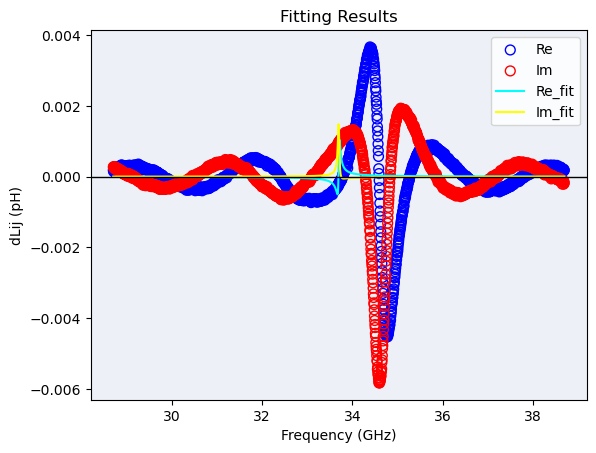

Final fit and results


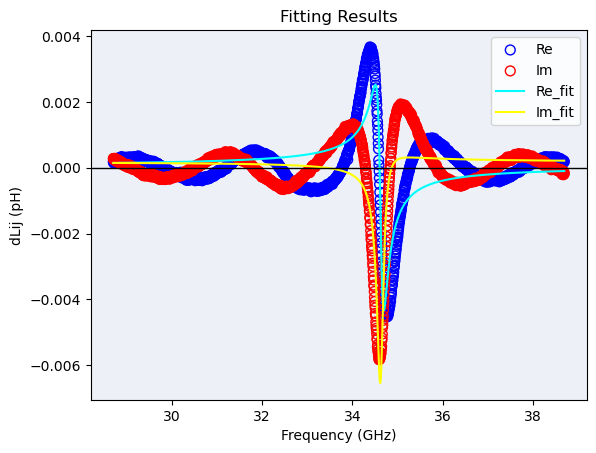


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -5.923e-04      1.108e-05         U        No
Ai                    -1.718e-04      1.108e-05         U        No
fo                       34.6312         0.0022       GHz        No
df                        0.0900         0.0022       GHz        No
re0                    4.515e-05      1.446e-05         U        No
im0                    1.753e-04      1.446e-05         U        No
----------------------------------------------------------------------
The phase is: 196.1752928979442


In [20]:
ini_vals = [1, 1, 35, 0.028, 0, 0] #A, w, fres, fper, fref, re0, im0
H_index = 41
f_center = 33.7

f_min, f_max = f_center-5, f_center+5 #GHz
f_array = ansy1.freqs

y_array_re, y_array_im = ansy1.d_S("21R")[H_index], ansy1.d_S("21I")[H_index]
#y_array_re, y_array_im = dS21_Re_dH[H_index], dS21_Im_dH[H_index]

model = models.ComplexLorentzian_freq()
fitter = fits.ComplexFitter( ini_vals, f_min, f_max,
    f_array, y_array_re , y_array_im, model)
fitter.fix(fo=f_center, df=0.02, re0=0, im0=0) # Parameters to be fixed, empty otherwise
opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
print(opt_p0)
print("Initial simplex fit")
fitter.plot_fit_simplex_wpm()

new_p0 = np.array(list(opt_p0.values()), dtype=float)
fitter.update_p0(new_p0)

params, cov = fitter.fit(simplex_b=False)
print("Final fit and results")
fitter.plot_fit()
fitter.summary()
print(f"The phase is: {model.phase_deg(**params)}")

In [21]:
#If we are happy with the fit, we can save it.

In [31]:
fit_dict = fitter.export_fit_dict()

fits_storage.save(index=H_index,val=float(ansy1.calc_field("inP")[H_index]),fit_dict=fit_dict)

In [ ]:
# Automatic fitting of entire spectra. Enter the estimated parameters for the Kittel model guiding the automatic fitting.

Index= 0, Guide freq.=51.13003502577238


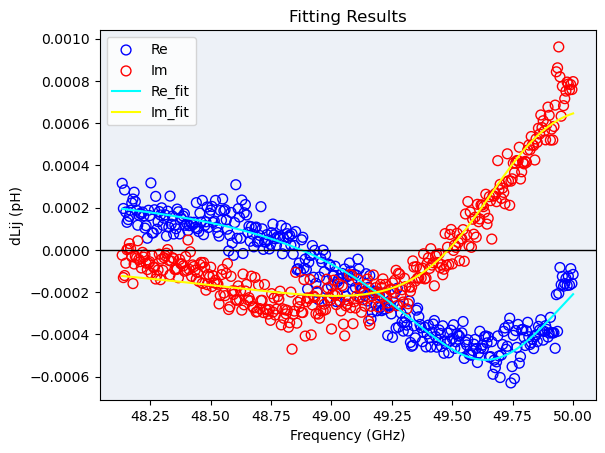


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.171e-04      1.636e-05         U        No
Ai                    -4.552e-04      1.636e-05         U        No
fo                       49.7033         0.0145       GHz        No
df                        0.5318         0.0145       GHz        No
re0                    3.491e-04      1.213e-05         U        No
im0                    1.135e-04      1.213e-05         U        No
----------------------------------------------------------------------
Index= 1, Guide freq.=50.812069284609926


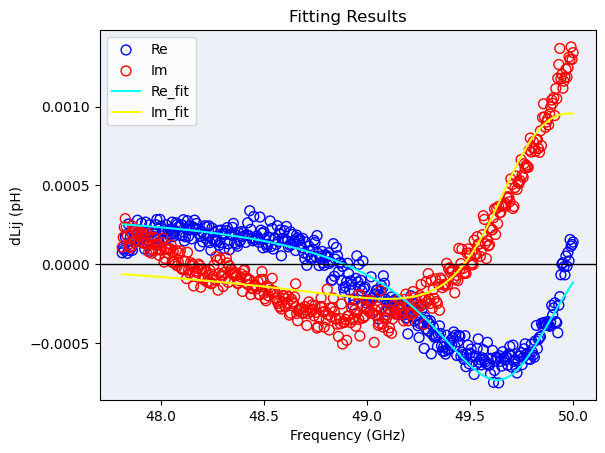


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.875e-04      1.423e-05         U        No
Ai                    -4.409e-04      1.423e-05         U        No
fo                       49.7148         0.0107       GHz        No
df                        0.4076         0.0107       GHz        No
re0                    3.958e-04      1.217e-05         U        No
im0                    1.390e-04      1.217e-05         U        No
----------------------------------------------------------------------
Index= 2, Guide freq.=50.48659613877436


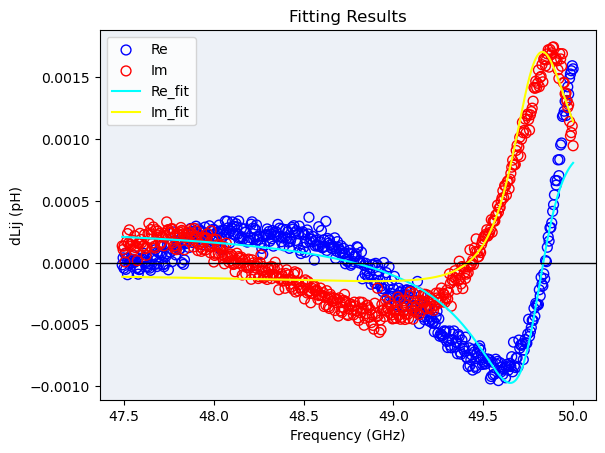


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.465e-04      1.034e-05         U        No
Ai                    -1.713e-04      1.034e-05         U        No
fo                       49.7798         0.0058       GHz        No
df                        0.2084         0.0058       GHz        No
re0                    3.668e-04      1.313e-05         U        No
im0                   -5.227e-05      1.313e-05         U        No
----------------------------------------------------------------------
Index= 3, Guide freq.=50.166267690553234


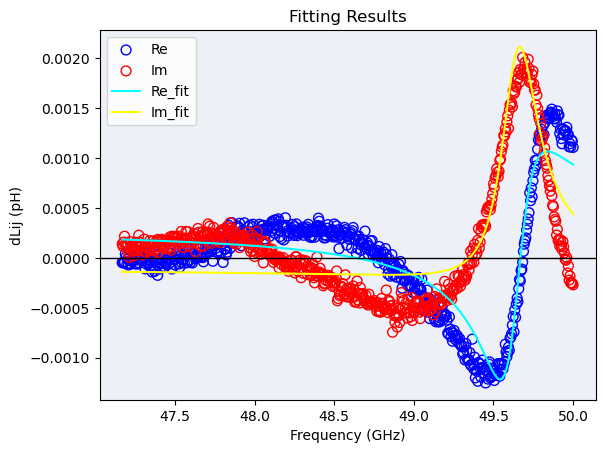


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.016e-04      7.410e-06         U        No
Ai                    -1.076e-04      7.410e-06         U        No
fo                       49.6404         0.0039       GHz        No
df                        0.1401         0.0039       GHz        No
re0                    3.091e-04      1.269e-05         U        No
im0                   -1.030e-04      1.269e-05         U        No
----------------------------------------------------------------------
Index= 4, Guide freq.=49.82335104562118


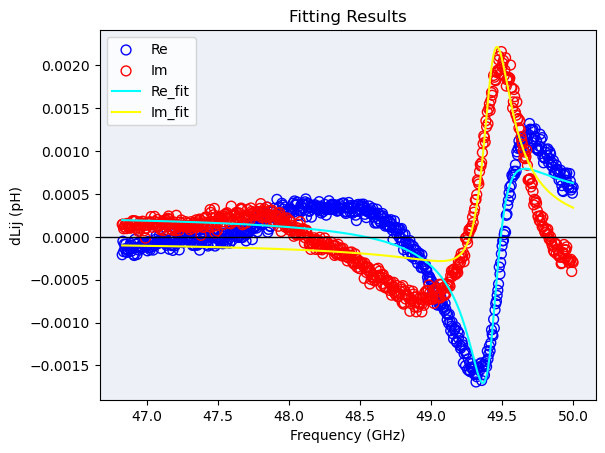


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.383e-04      6.857e-06         U        No
Ai                    -1.769e-04      6.857e-06         U        No
fo                       49.4253         0.0035       GHz        No
df                        0.1187         0.0035       GHz        No
re0                    2.897e-04      1.286e-05         U        No
im0                   -3.707e-05      1.286e-05         U        No
----------------------------------------------------------------------
Index= 5, Guide freq.=49.46980637345207


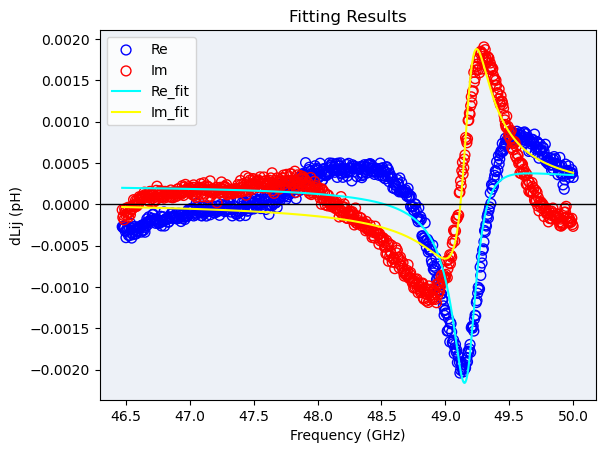


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.224e-04      6.862e-06         U        No
Ai                    -2.535e-04      6.862e-06         U        No
fo                       49.1752         0.0035       GHz        No
df                        0.1111         0.0035       GHz        No
re0                    2.482e-04      1.295e-05         U        No
im0                    5.924e-05      1.295e-05         U        No
----------------------------------------------------------------------
Index= 6, Guide freq.=49.10434977791998


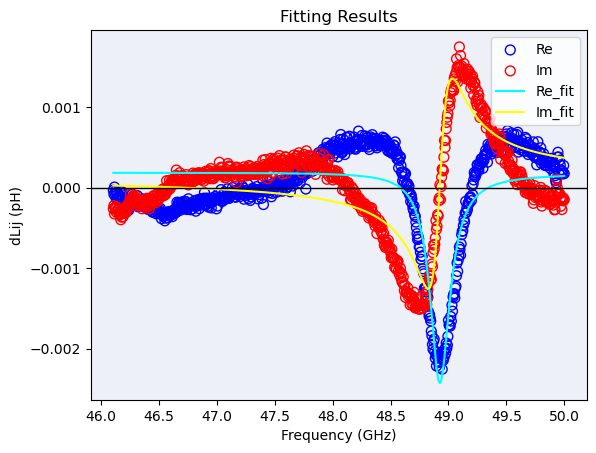


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.499e-05      6.789e-06         U        No
Ai                    -2.715e-04      6.789e-06         U        No
fo                       48.9229         0.0034       GHz        No
df                        0.1042         0.0034       GHz        No
re0                    1.814e-04      1.277e-05         U        No
im0                    1.214e-04      1.277e-05         U        No
----------------------------------------------------------------------
Index= 7, Guide freq.=48.725703876237624


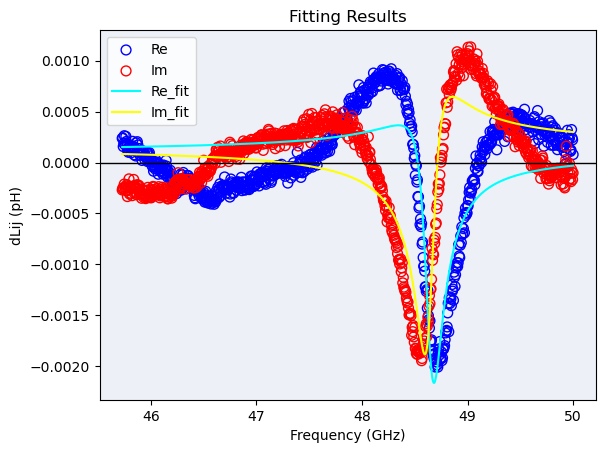


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.609e-04      6.766e-06         U        No
Ai                    -2.069e-04      6.766e-06         U        No
fo                       48.6463         0.0036       GHz        No
df                        0.1036         0.0036       GHz        No
re0                    9.921e-05      1.228e-05         U        No
im0                    1.567e-04      1.228e-05         U        No
----------------------------------------------------------------------
Index= 8, Guide freq.=48.3166401226488


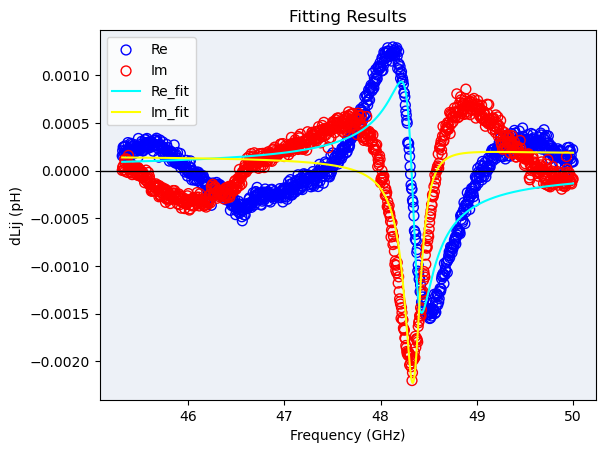


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.418e-04      6.549e-06         U        No
Ai                    -6.006e-05      6.549e-06         U        No
fo                       48.3472         0.0036       GHz        No
df                        0.1027         0.0036       GHz        No
re0                    1.390e-05      1.146e-05         U        No
im0                    1.615e-04      1.146e-05         U        No
----------------------------------------------------------------------
Index= 9, Guide freq.=47.90756023568538


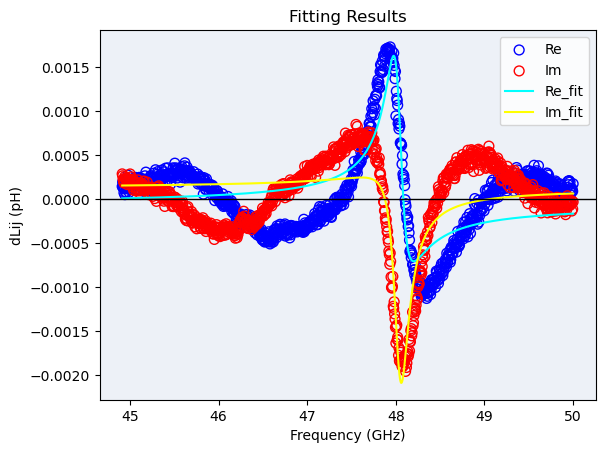


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.118e-04      6.287e-06         U        No
Ai                     1.057e-04      6.287e-06         U        No
fo                       48.0375         0.0036       GHz        No
df                        0.1012         0.0036       GHz        No
re0                   -6.037e-05      1.068e-05         U        No
im0                    1.233e-04      1.068e-05         U        No
----------------------------------------------------------------------
Index= 10, Guide freq.=47.49956112128838


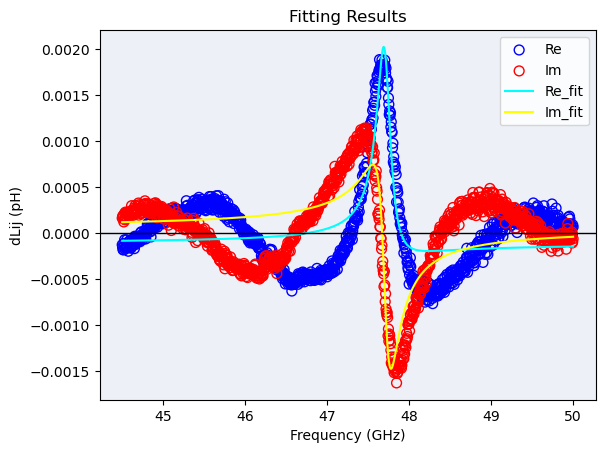


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.639e-05      6.158e-06         U        No
Ai                     2.115e-04      6.158e-06         U        No
fo                       47.7101         0.0038       GHz        No
df                        0.1030         0.0038       GHz        No
re0                   -1.108e-04      9.998e-06         U        No
im0                    5.564e-05      9.998e-06         U        No
----------------------------------------------------------------------
Index= 11, Guide freq.=47.058139545720536


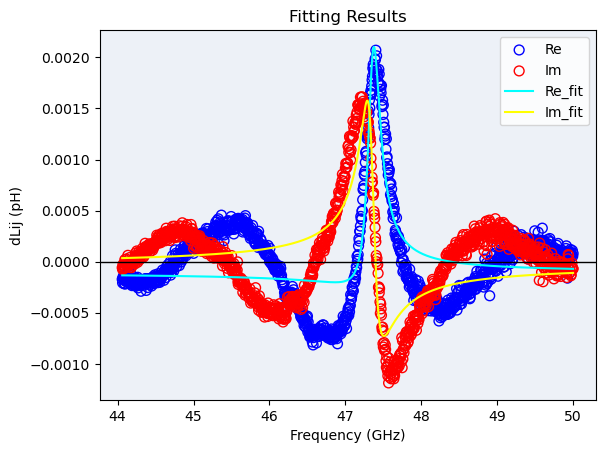


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     9.180e-05      6.145e-06         U        No
Ai                     2.135e-04      6.145e-06         U        No
fo                       47.3552         0.0036       GHz        No
df                        0.1009         0.0036       GHz        No
re0                   -1.079e-04      9.725e-06         U        No
im0                   -3.064e-05      9.725e-06         U        No
----------------------------------------------------------------------
Index= 12, Guide freq.=46.58107938465981


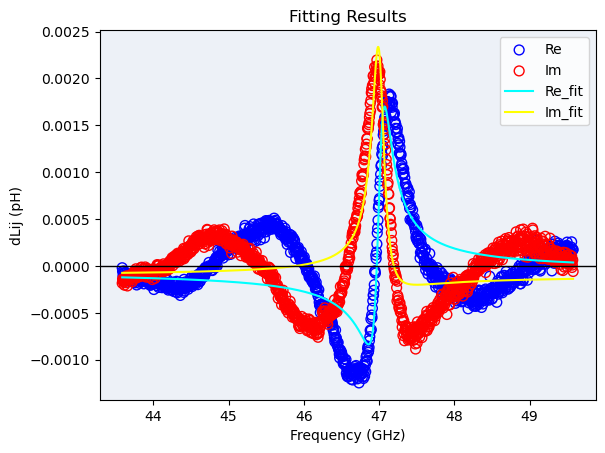


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.323e-04      6.387e-06         U        No
Ai                     9.634e-05      6.387e-06         U        No
fo                       47.0074         0.0034       GHz        No
df                        0.0991         0.0034       GHz        No
re0                   -5.488e-05      1.016e-05         U        No
im0                   -1.041e-04      1.016e-05         U        No
----------------------------------------------------------------------
Index= 13, Guide freq.=46.10524615679419


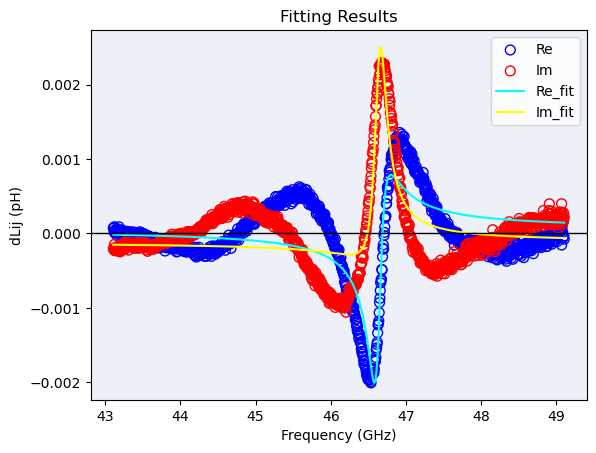


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.381e-04      6.561e-06         U        No
Ai                    -1.280e-04      6.561e-06         U        No
fo                       46.6385         0.0032       GHz        No
df                        0.0969         0.0032       GHz        No
re0                    5.174e-05      1.056e-05         U        No
im0                   -1.167e-04      1.056e-05         U        No
----------------------------------------------------------------------
Index= 14, Guide freq.=45.613172159195265


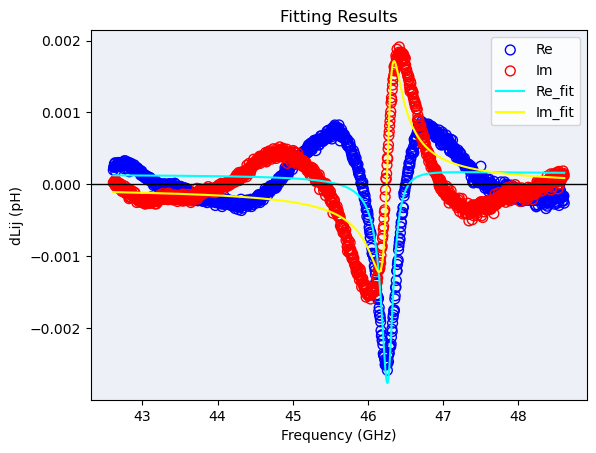


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.452e-05      6.775e-06         U        No
Ai                    -2.797e-04      6.775e-06         U        No
fo                       46.2664         0.0031       GHz        No
df                        0.0971         0.0031       GHz        No
re0                    1.413e-04      1.088e-05         U        No
im0                   -3.349e-05      1.088e-05         U        No
----------------------------------------------------------------------
Index= 15, Guide freq.=45.10576942946452


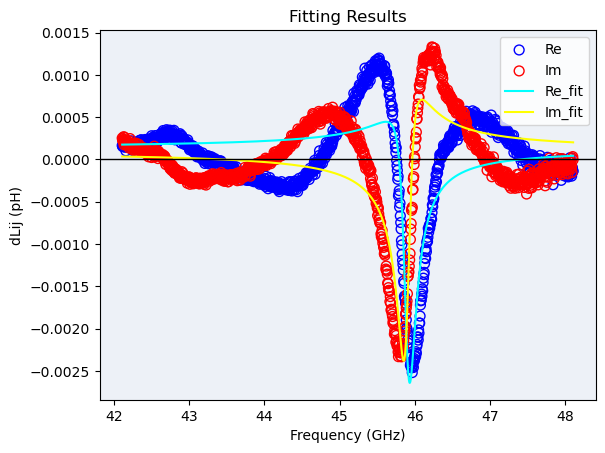


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.801e-04      6.793e-06         U        No
Ai                    -2.365e-04      6.793e-06         U        No
fo                       45.8999         0.0030       GHz        No
df                        0.0963         0.0030       GHz        No
re0                    1.294e-04      1.095e-05         U        No
im0                    9.853e-05      1.095e-05         U        No
----------------------------------------------------------------------
Index= 16, Guide freq.=44.58430495251244


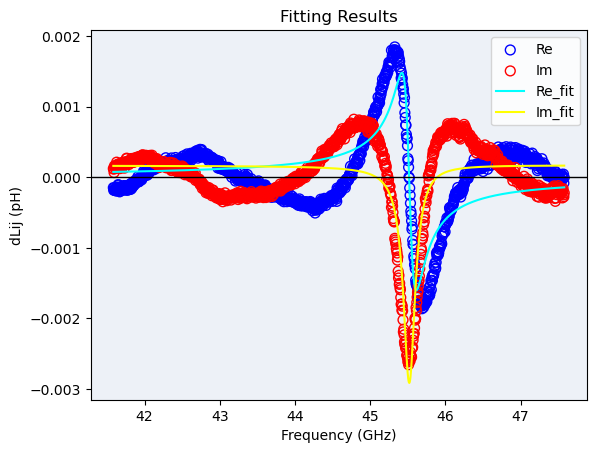


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.959e-04      6.821e-06         U        No
Ai                    -1.185e-05      6.821e-06         U        No
fo                       45.5212         0.0030       GHz        No
df                        0.0961         0.0030       GHz        No
re0                    1.161e-06      1.100e-05         U        No
im0                    1.663e-04      1.100e-05         U        No
----------------------------------------------------------------------
Index= 17, Guide freq.=44.05037143875068


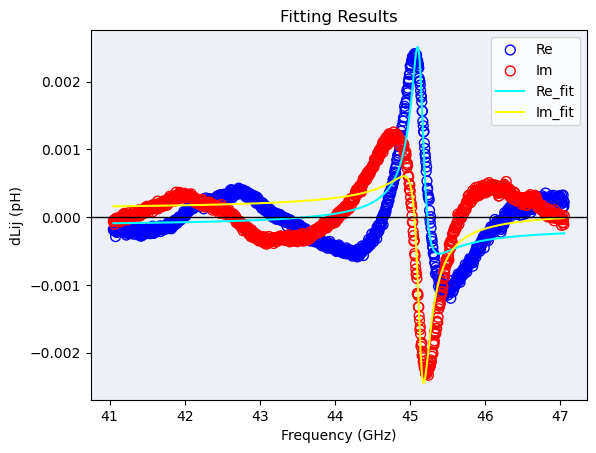


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.999e-04      6.802e-06         U        No
Ai                     2.191e-04      6.802e-06         U        No
fo                       45.1369         0.0030       GHz        No
df                        0.0972         0.0030       GHz        No
re0                   -1.398e-04      1.089e-05         U        No
im0                    1.078e-04      1.089e-05         U        No
----------------------------------------------------------------------
Index= 18, Guide freq.=43.50584574021396


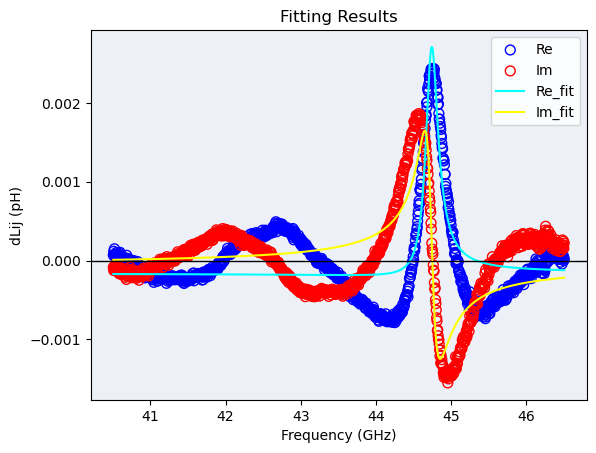


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.194e-05      6.788e-06         U        No
Ai                     2.859e-04      6.788e-06         U        No
fo                       44.7345         0.0032       GHz        No
df                        0.1004         0.0032       GHz        No
re0                   -1.603e-04      1.067e-05         U        No
im0                   -5.870e-05      1.067e-05         U        No
----------------------------------------------------------------------
Index= 19, Guide freq.=42.95283663614127


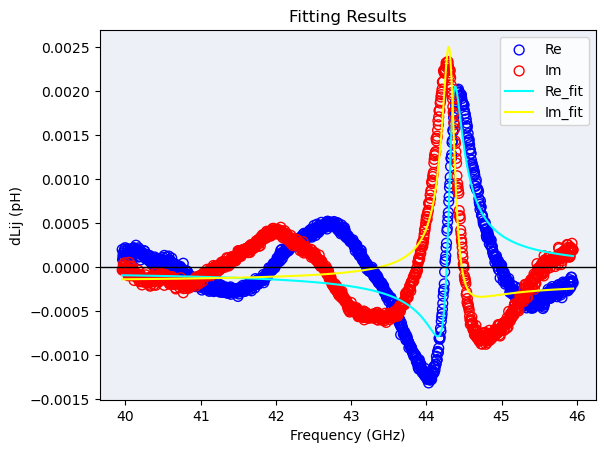


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.540e-04      6.812e-06         U        No
Ai                     1.353e-04      6.812e-06         U        No
fo                       44.3218         0.0033       GHz        No
df                        0.1015         0.0033       GHz        No
re0                   -3.397e-05      1.064e-05         U        No
im0                   -1.696e-04      1.064e-05         U        No
----------------------------------------------------------------------
Index= 20, Guide freq.=42.39362399768023


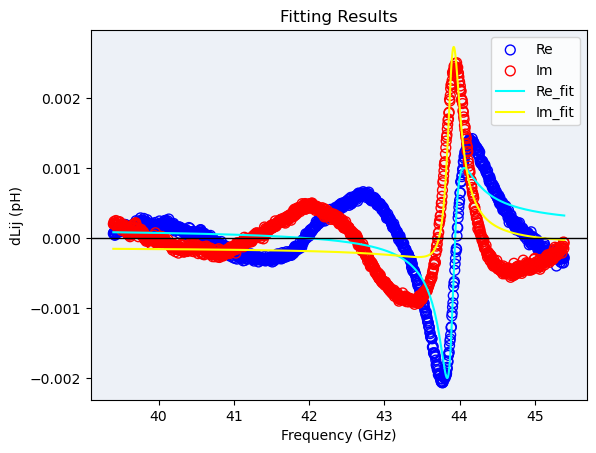


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.747e-04      7.062e-06         U        No
Ai                    -1.305e-04      7.062e-06         U        No
fo                       43.8995         0.0032       GHz        No
df                        0.1012         0.0032       GHz        No
re0                    1.449e-04      1.103e-05         U        No
im0                   -1.263e-04      1.103e-05         U        No
----------------------------------------------------------------------
Index= 21, Guide freq.=41.853155846815866


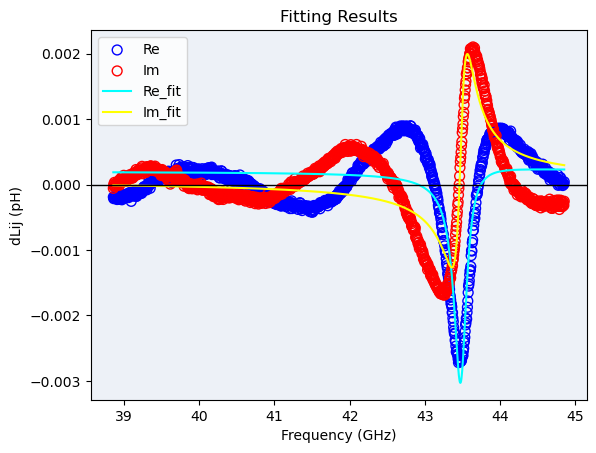


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.187e-05      7.627e-06         U        No
Ai                    -3.240e-04      7.627e-06         U        No
fo                       43.4806         0.0032       GHz        No
df                        0.1011         0.0032       GHz        No
re0                    2.023e-04      1.190e-05         U        No
im0                    5.761e-05      1.190e-05         U        No
----------------------------------------------------------------------
Index= 22, Guide freq.=41.266155619424886


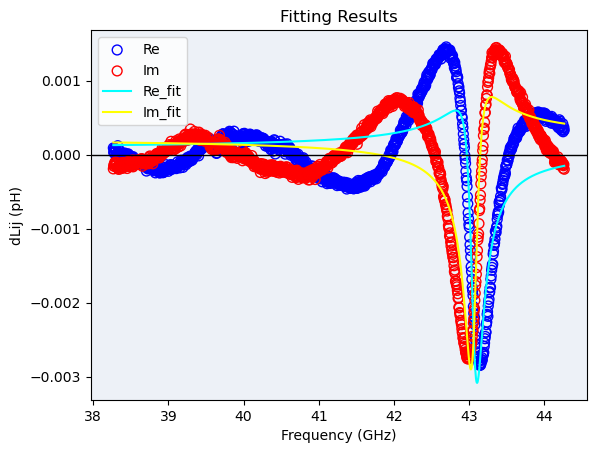


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.538e-04      7.964e-06         U        No
Ai                    -2.614e-04      7.964e-06         U        No
fo                       43.0639         0.0029       GHz        No
df                        0.0990         0.0029       GHz        No
re0                    7.567e-05      1.252e-05         U        No
im0                    2.192e-04      1.252e-05         U        No
----------------------------------------------------------------------
Index= 23, Guide freq.=40.702692243661716


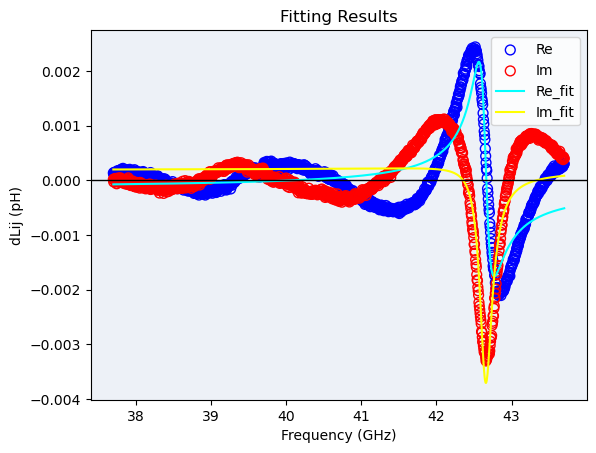


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.880e-04      8.215e-06         U        No
Ai                     7.188e-05      8.215e-06         U        No
fo                       42.6479         0.0028       GHz        No
df                        0.1004         0.0028       GHz        No
re0                   -1.525e-04      1.277e-05         U        No
im0                    1.857e-04      1.277e-05         U        No
----------------------------------------------------------------------
Index= 24, Guide freq.=40.14246523182852


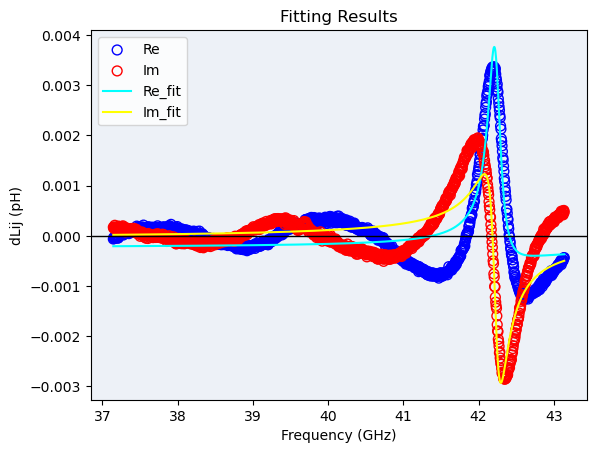


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.602e-04      8.175e-06         U        No
Ai                     3.882e-04      8.175e-06         U        No
fo                       42.2293         0.0026       GHz        No
df                        0.1009         0.0026       GHz        No
re0                   -2.402e-04      1.262e-05         U        No
im0                   -5.666e-05      1.262e-05         U        No
----------------------------------------------------------------------
Index= 25, Guide freq.=39.587557495158215


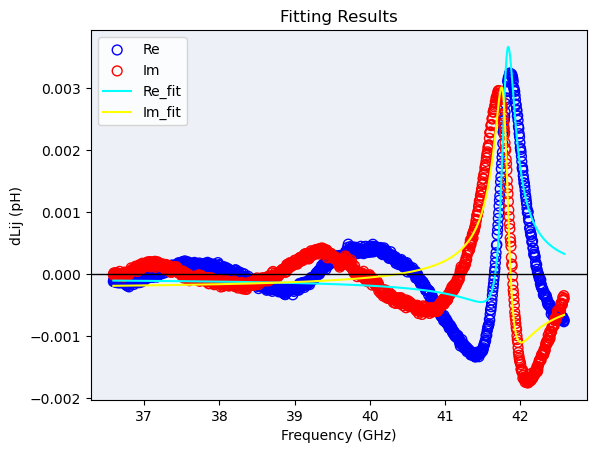


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.565e-04      8.173e-06         U        No
Ai                     3.523e-04      8.173e-06         U        No
fo                       41.8061         0.0026       GHz        No
df                        0.1059         0.0026       GHz        No
re0                   -5.346e-05      1.221e-05         U        No
im0                   -2.540e-04      1.221e-05         U        No
----------------------------------------------------------------------
Index= 26, Guide freq.=39.03980806042238


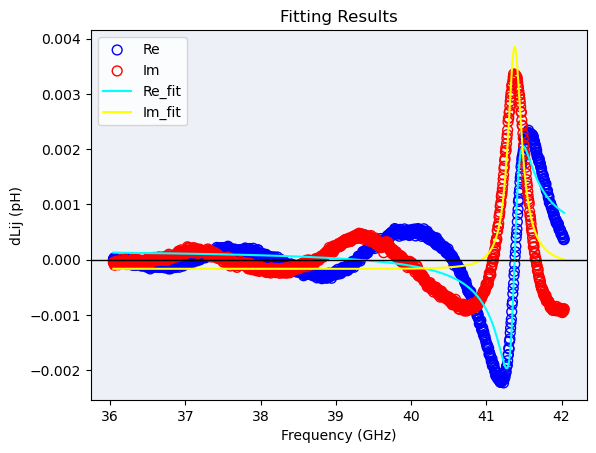


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.399e-04      7.880e-06         U        No
Ai                    -3.723e-05      7.880e-06         U        No
fo                       41.3716         0.0026       GHz        No
df                        0.1099         0.0026       GHz        No
re0                    2.097e-04      1.143e-05         U        No
im0                   -1.600e-04      1.143e-05         U        No
----------------------------------------------------------------------
Index= 27, Guide freq.=38.500756929958534


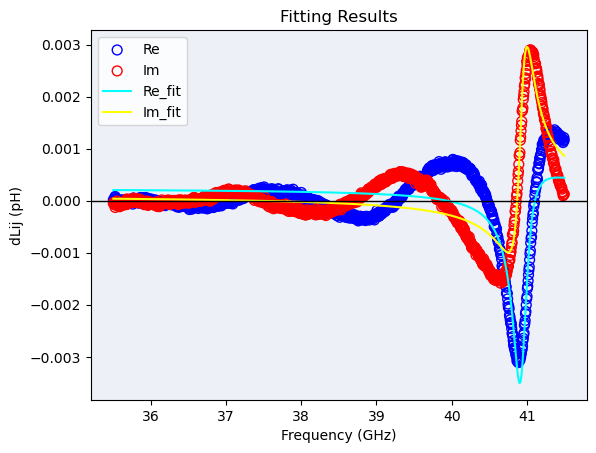


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.972e-04      7.892e-06         U        No
Ai                    -4.018e-04      7.892e-06         U        No
fo                       40.9309         0.0026       GHz        No
df                        0.1133         0.0026       GHz        No
re0                    2.436e-04      1.114e-05         U        No
im0                    1.123e-04      1.114e-05         U        No
----------------------------------------------------------------------
Index= 28, Guide freq.=37.97159975514156


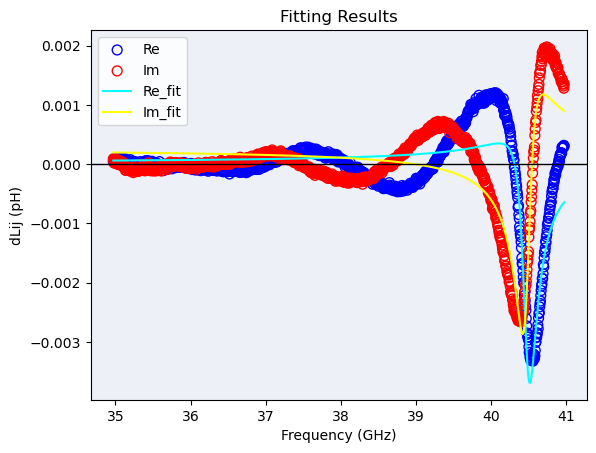


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.529e-04      8.031e-06         U        No
Ai                    -3.833e-04      8.031e-06         U        No
fo                       40.4795         0.0026       GHz        No
df                        0.1135         0.0026       GHz        No
re0                    1.787e-05      1.121e-05         U        No
im0                    2.693e-04      1.121e-05         U        No
----------------------------------------------------------------------
Index= 29, Guide freq.=37.47367959510568


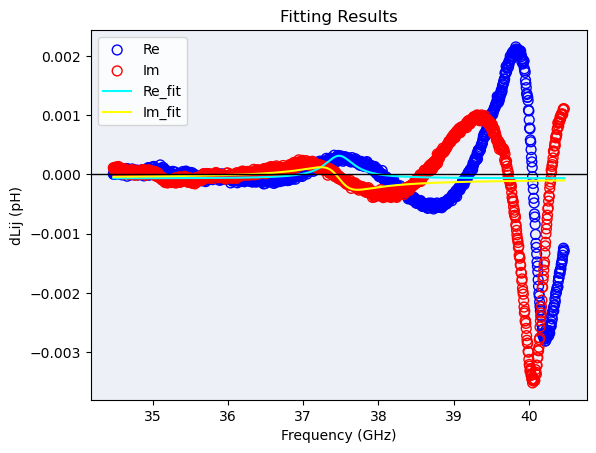


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     9.230e-07      2.506e-05         U        No
Ai                     9.300e-05      2.506e-05         U        No
fo                       37.4775         0.0849       GHz        No
df                        0.2439         0.0849       GHz        No
re0                   -6.648e-05      2.460e-05         U        No
im0                   -7.084e-05      2.460e-05         U        No
----------------------------------------------------------------------
Index= 30, Guide freq.=36.94583787449906


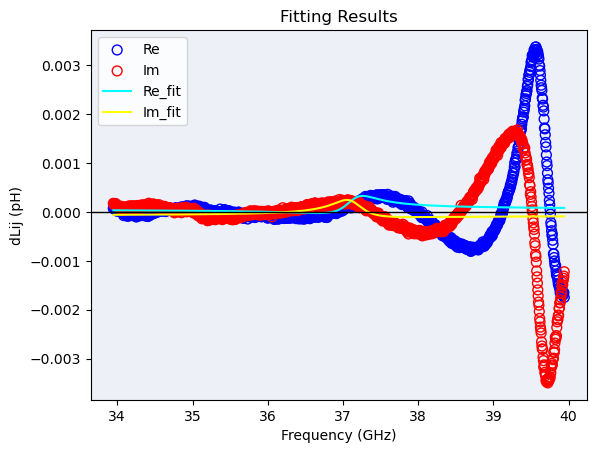


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     7.287e-05      2.595e-05         U        No
Ai                     4.877e-05      2.595e-05         U        No
fo                       37.1276         0.0953       GHz        No
df                        0.2500         0.0953       GHz        No
re0                    5.337e-05      2.512e-05         U        No
im0                   -7.706e-05      2.512e-05         U        No
----------------------------------------------------------------------
Index= 31, Guide freq.=36.46929969218876


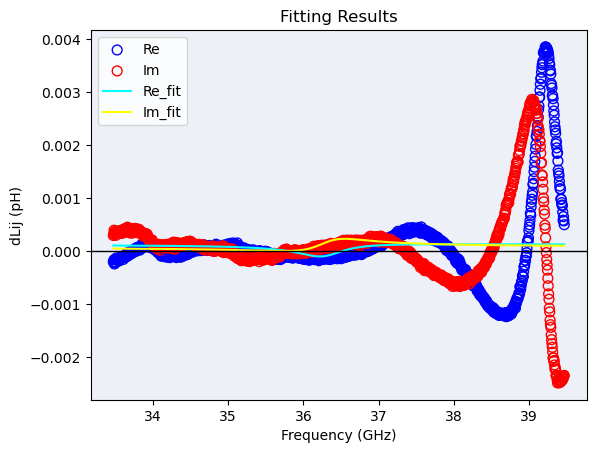


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.249e-05      3.607e-05         U        No
Ai                    -8.103e-05      3.607e-05         U        No
fo                       36.2909         0.1927       GHz        No
df                        0.3798         0.1927       GHz        No
re0                    1.171e-04      2.749e-05         U        No
im0                    7.108e-05      2.749e-05         U        No
----------------------------------------------------------------------
Index= 32, Guide freq.=35.98346000644201


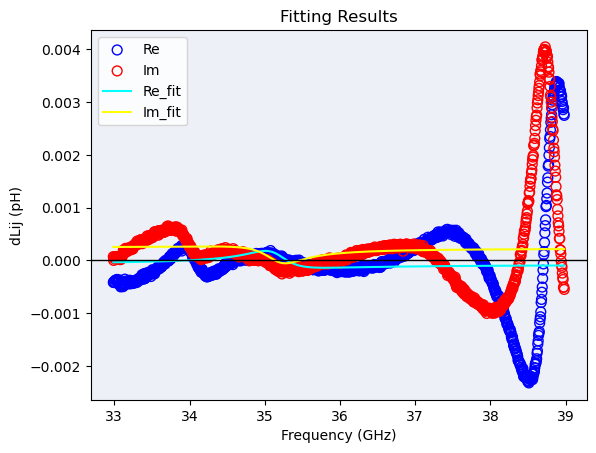


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.086e-05      3.295e-05         U        No
Ai                     6.155e-05      3.295e-05         U        No
fo                       35.1670         0.1288       GHz        No
df                        0.3179         0.1288       GHz        No
re0                   -7.513e-05      2.768e-05         U        No
im0                    2.334e-04      2.768e-05         U        No
----------------------------------------------------------------------
Index= 33, Guide freq.=35.48880476624966


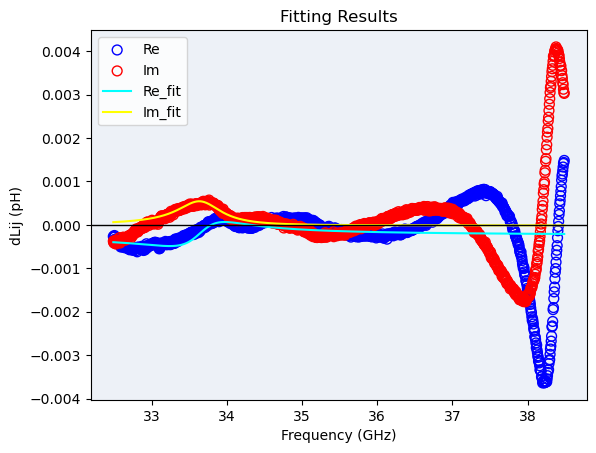


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.984e-04      3.914e-05         U        No
Ai                     2.881e-05      3.914e-05         U        No
fo                       33.6598         0.0838       GHz        No
df                        0.3613         0.0838       GHz        No
re0                   -2.513e-04      2.925e-05         U        No
im0                   -8.724e-06      2.925e-05         U        No
----------------------------------------------------------------------
Index= 34, Guide freq.=35.04075015226756


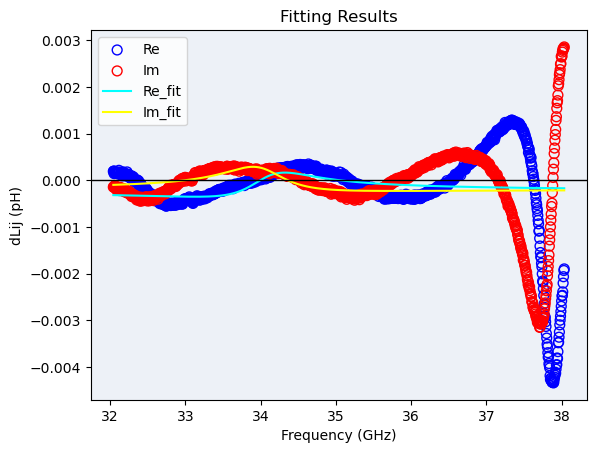


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.217e-04      4.932e-05         U        No
Ai                     1.374e-04      4.932e-05         U        No
fo                       34.0406         0.1106       GHz        No
df                        0.5051         0.1106       GHz        No
re0                   -2.291e-04      3.119e-05         U        No
im0                   -1.885e-04      3.119e-05         U        No
----------------------------------------------------------------------
Index= 35, Guide freq.=34.58137917863292


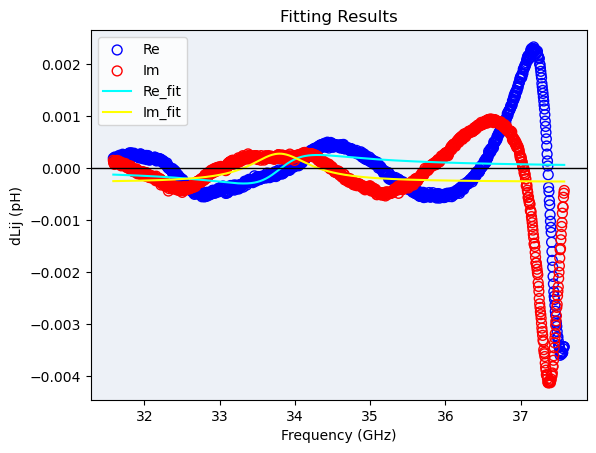


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.682e-04      4.732e-05         U        No
Ai                    -1.433e-05      4.732e-05         U        No
fo                       33.7833         0.1010       GHz        No
df                        0.4896         0.1010       GHz        No
re0                   -6.820e-06      3.069e-05         U        No
im0                   -2.698e-04      3.069e-05         U        No
----------------------------------------------------------------------
Index= 36, Guide freq.=34.10984127787832


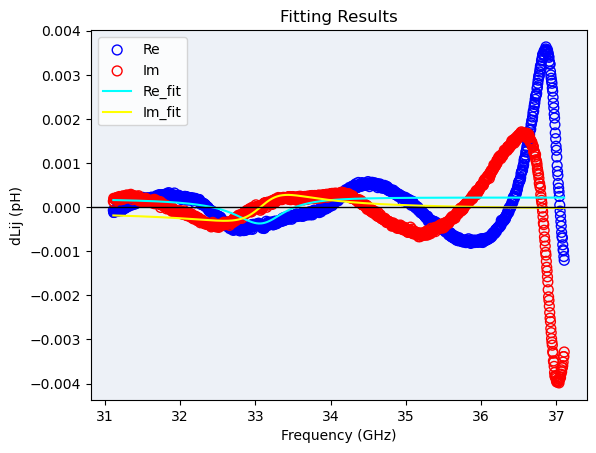


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.224e-05      4.078e-05         U        No
Ai                    -2.352e-04      4.078e-05         U        No
fo                       33.0996         0.0834       GHz        No
df                        0.4101         0.0834       GHz        No
re0                    2.088e-04      2.934e-05         U        No
im0                   -8.042e-05      2.934e-05         U        No
----------------------------------------------------------------------
Index= 37, Guide freq.=33.67843821489761


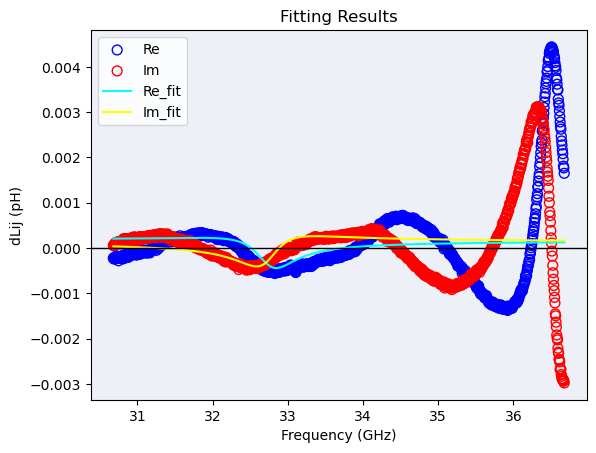


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.239e-04      3.598e-05         U        No
Ai                    -1.699e-04      3.598e-05         U        No
fo                       32.7432         0.0672       GHz        No
df                        0.3146         0.0672       GHz        No
re0                    1.614e-04      3.035e-05         U        No
im0                    1.251e-04      3.035e-05         U        No
----------------------------------------------------------------------
Index= 38, Guide freq.=33.213226135435484


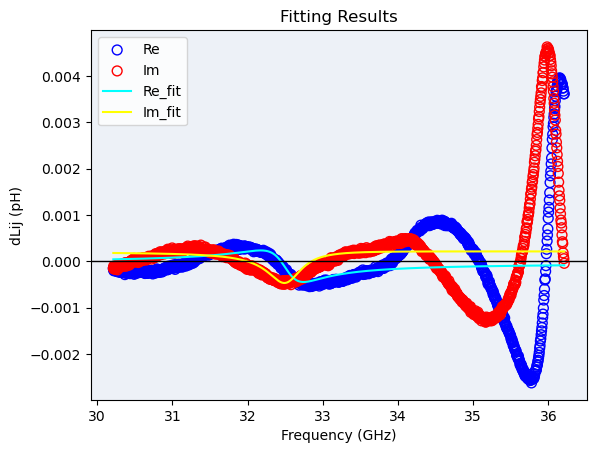


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.865e-04      3.503e-05         U        No
Ai                    -3.962e-05      3.503e-05         U        No
fo                       32.5180         0.0652       GHz        No
df                        0.2796         0.0652       GHz        No
re0                   -3.704e-05      3.173e-05         U        No
im0                    2.042e-04      3.173e-05         U        No
----------------------------------------------------------------------
Index= 39, Guide freq.=32.76599288788009


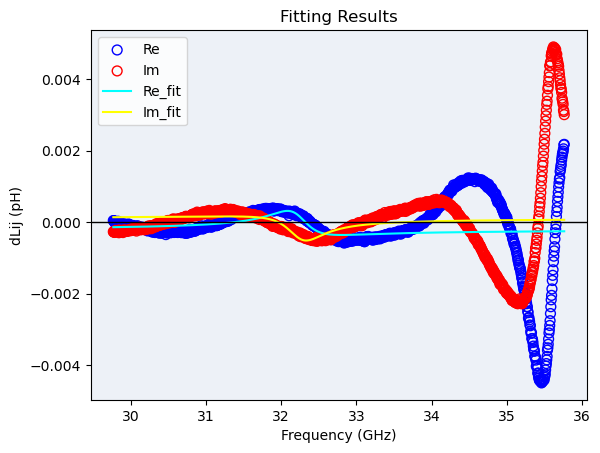


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.653e-04      4.023e-05         U        No
Ai                     1.127e-04      4.023e-05         U        No
fo                       32.2414         0.0754       GHz        No
df                        0.2966         0.0754       GHz        No
re0                   -2.131e-04      3.530e-05         U        No
im0                    9.998e-05      3.530e-05         U        No
----------------------------------------------------------------------
Index= 40, Guide freq.=32.316882765937564


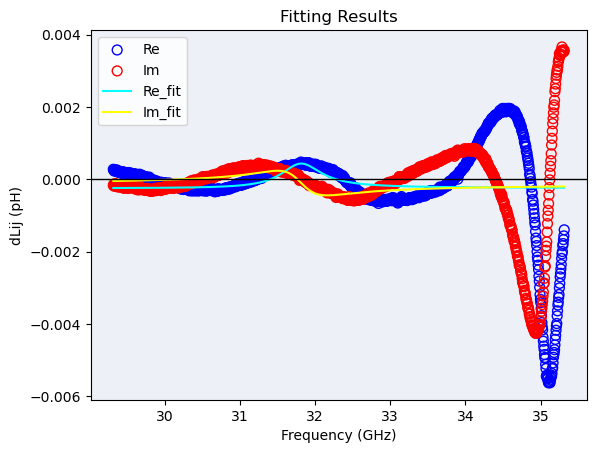


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.184e-05      4.705e-05         U        No
Ai                     2.230e-04      4.705e-05         U        No
fo                       31.8008         0.0863       GHz        No
df                        0.3291         0.0863       GHz        No
re0                   -2.454e-04      3.890e-05         U        No
im0                   -1.382e-04      3.890e-05         U        No
----------------------------------------------------------------------
Index= 41, Guide freq.=31.86407154787377


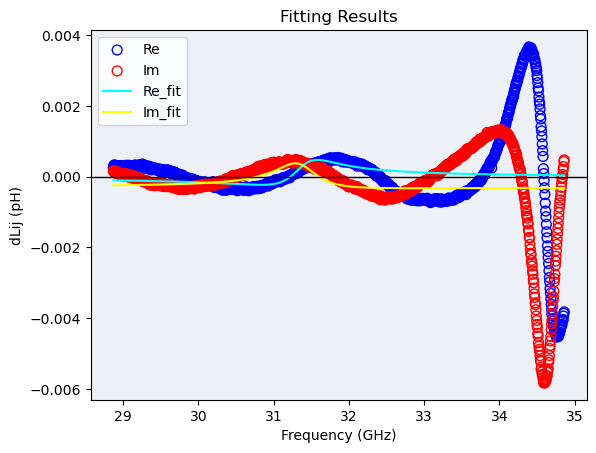


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.198e-04      4.972e-05         U        No
Ai                     1.002e-04      4.972e-05         U        No
fo                       31.3633         0.0876       GHz        No
df                        0.3428         0.0876       GHz        No
re0                   -2.309e-05      4.015e-05         U        No
im0                   -2.940e-04      4.015e-05         U        No
----------------------------------------------------------------------
Index= 42, Guide freq.=31.40591118870951


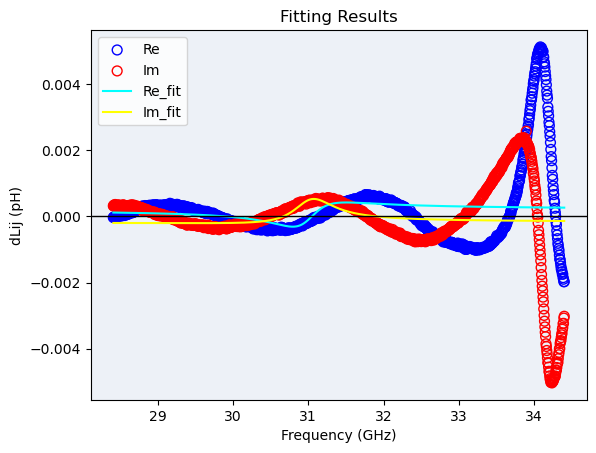


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.173e-04      4.502e-05         U        No
Ai                    -9.667e-05      4.502e-05         U        No
fo                       31.0046         0.0769       GHz        No
df                        0.3247         0.0769       GHz        No
re0                    2.051e-04      3.754e-05         U        No
im0                   -1.714e-04      3.754e-05         U        No
----------------------------------------------------------------------
Index= 43, Guide freq.=30.94098712959532


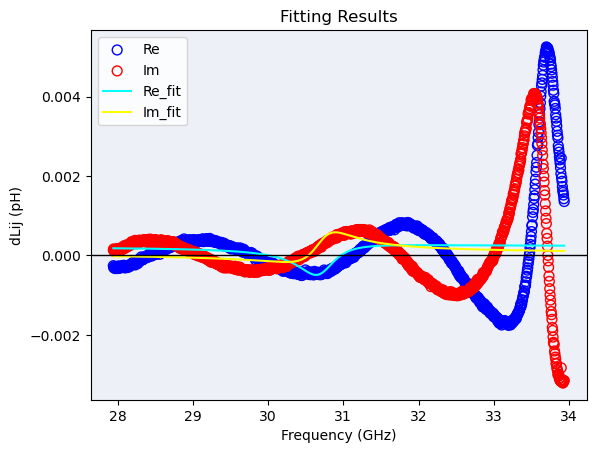


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     9.520e-05      4.186e-05         U        No
Ai                    -2.026e-04      4.186e-05         U        No
fo                       30.7042         0.0707       GHz        No
df                        0.2989         0.0707       GHz        No
re0                    2.223e-04      3.663e-05         U        No
im0                    4.888e-05      3.663e-05         U        No
----------------------------------------------------------------------
Index= 44, Guide freq.=30.468165007556877


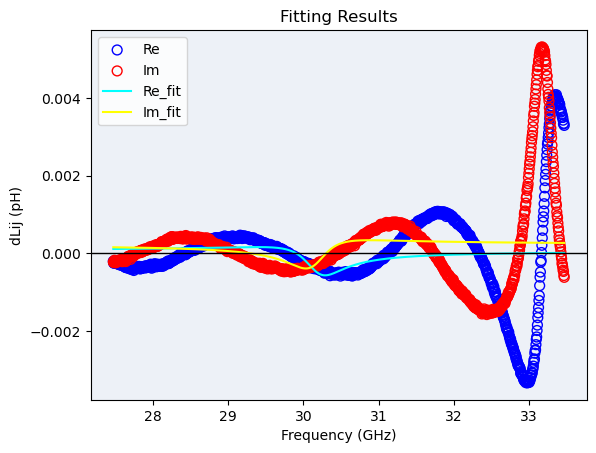


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.544e-04      4.506e-05         U        No
Ai                    -1.643e-04      4.506e-05         U        No
fo                       30.1657         0.0779       GHz        No
df                        0.3093         0.0779       GHz        No
re0                    6.152e-05      3.866e-05         U        No
im0                    2.224e-04      3.866e-05         U        No
----------------------------------------------------------------------
Index= 45, Guide freq.=29.986624659863274


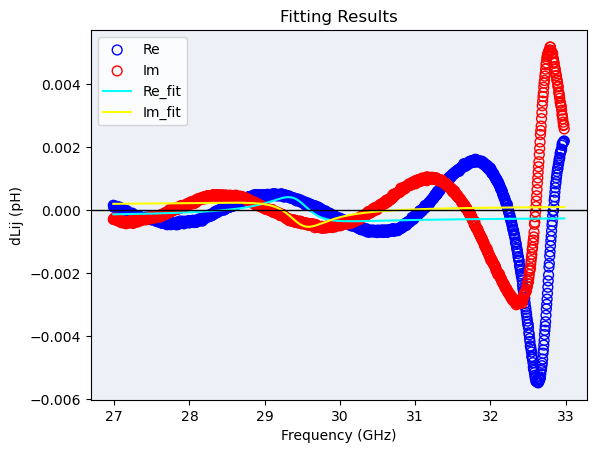


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.887e-04      5.093e-05         U        No
Ai                     1.574e-04      5.093e-05         U        No
fo                       29.4652         0.0833       GHz        No
df                        0.3211         0.0833       GHz        No
re0                   -2.128e-04      4.270e-05         U        No
im0                    1.495e-04      4.270e-05         U        No
----------------------------------------------------------------------
Index= 46, Guide freq.=29.49587967745773


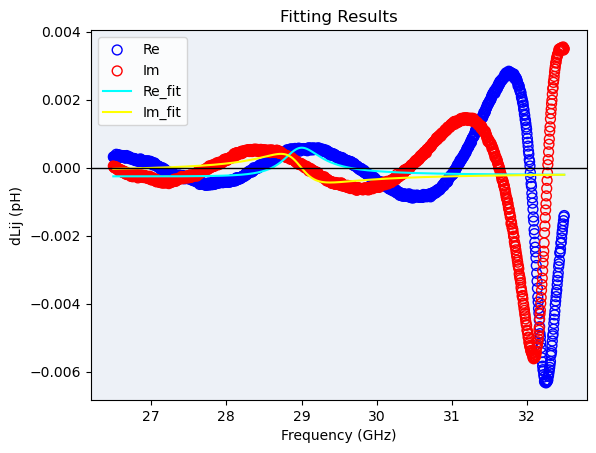


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     7.757e-05      5.577e-05         U        No
Ai                     2.518e-04      5.577e-05         U        No
fo                       28.9553         0.0831       GHz        No
df                        0.3125         0.0831       GHz        No
re0                   -2.373e-04      4.749e-05         U        No
im0                   -1.401e-04      4.749e-05         U        No
----------------------------------------------------------------------
Index= 47, Guide freq.=28.995781165589804


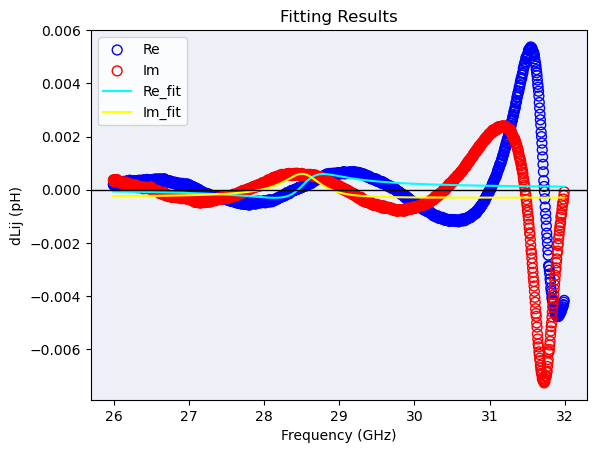


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.712e-04      5.946e-05         U        No
Ai                     6.708e-05      5.946e-05         U        No
fo                       28.5443         0.0836       GHz        No
df                        0.3124         0.0836       GHz        No
re0                    3.510e-05      5.068e-05         U        No
im0                   -2.851e-04      5.068e-05         U        No
----------------------------------------------------------------------
Index= 48, Guide freq.=28.486504812713864


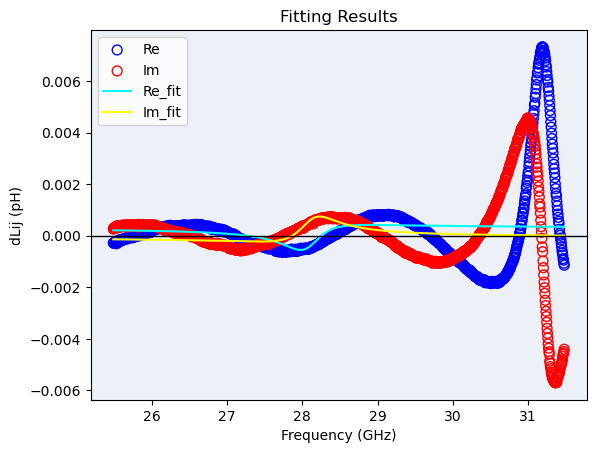


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.963e-04      5.846e-05         U        No
Ai                    -2.193e-04      5.846e-05         U        No
fo                       28.0939         0.0760       GHz        No
df                        0.3033         0.0760       GHz        No
re0                    2.942e-04      5.070e-05         U        No
im0                   -6.558e-05      5.070e-05         U        No
----------------------------------------------------------------------
Index= 49, Guide freq.=27.968520851899445


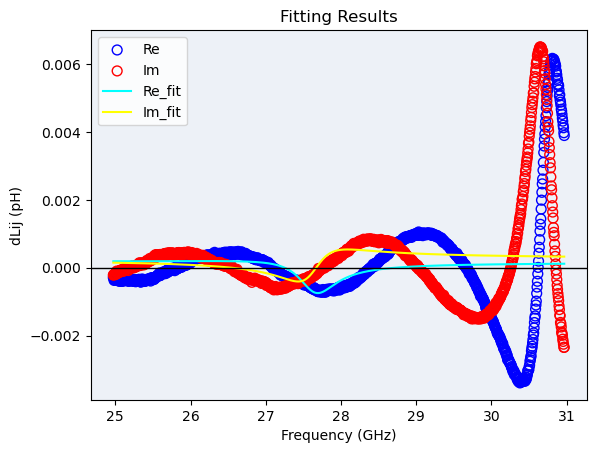


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.129e-04      5.579e-05         U        No
Ai                    -2.634e-04      5.579e-05         U        No
fo                       27.6287         0.0744       GHz        No
df                        0.3029         0.0744       GHz        No
re0                    1.594e-04      4.843e-05         U        No
im0                    2.534e-04      4.843e-05         U        No
----------------------------------------------------------------------
Index= 50, Guide freq.=27.442547027790496


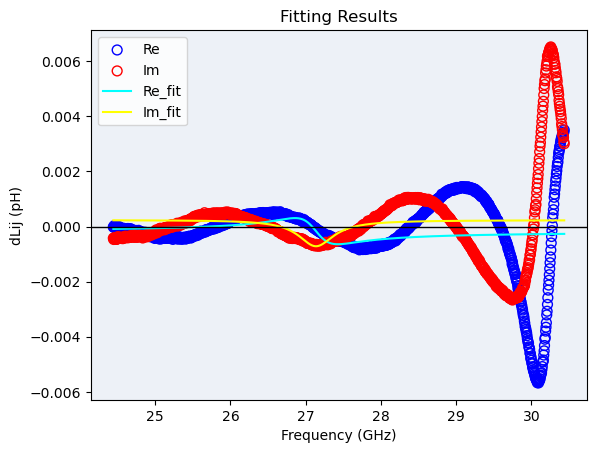


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.710e-04      5.235e-05         U        No
Ai                     1.031e-05      5.235e-05         U        No
fo                       27.1322         0.0701       GHz        No
df                        0.2856         0.0701       GHz        No
re0                   -1.856e-04      4.700e-05         U        No
im0                    2.336e-04      4.700e-05         U        No
----------------------------------------------------------------------
Index= 51, Guide freq.=26.909485265736922


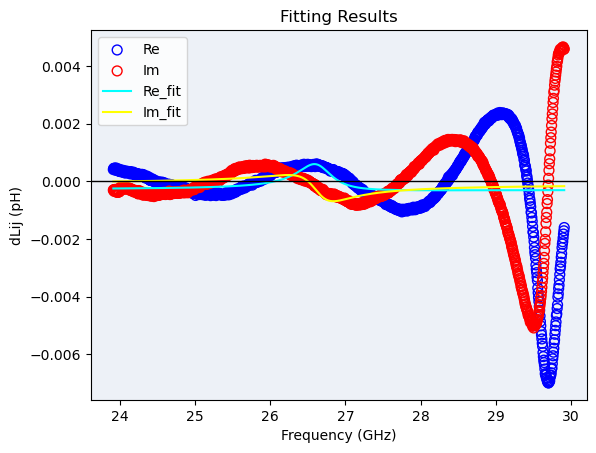


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.249e-05      5.485e-05         U        No
Ai                     2.463e-04      5.485e-05         U        No
fo                       26.6332         0.0767       GHz        No
df                        0.2859         0.0767       GHz        No
re0                   -2.882e-04      4.922e-05         U        No
im0                   -9.232e-05      4.922e-05         U        No
----------------------------------------------------------------------
Index= 52, Guide freq.=26.37034338837115


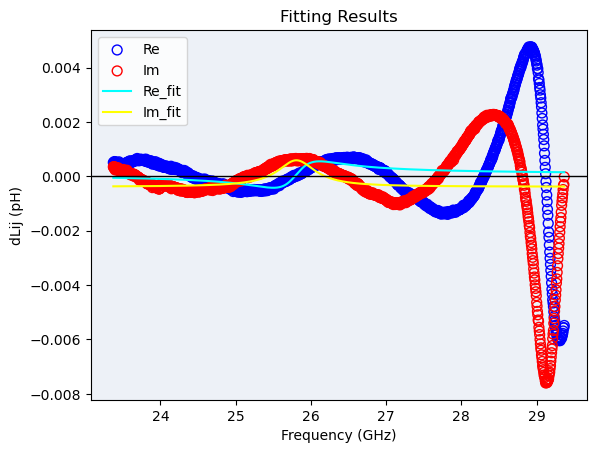


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.000e-04      6.313e-05         U        No
Ai                    -1.022e-06      6.313e-05         U        No
fo                       25.8069         0.0815       GHz        No
df                        0.3080         0.0815       GHz        No
re0                    7.025e-05      5.420e-05         U        No
im0                   -3.803e-04      5.420e-05         U        No
----------------------------------------------------------------------
Index= 53, Guide freq.=25.826143945880514


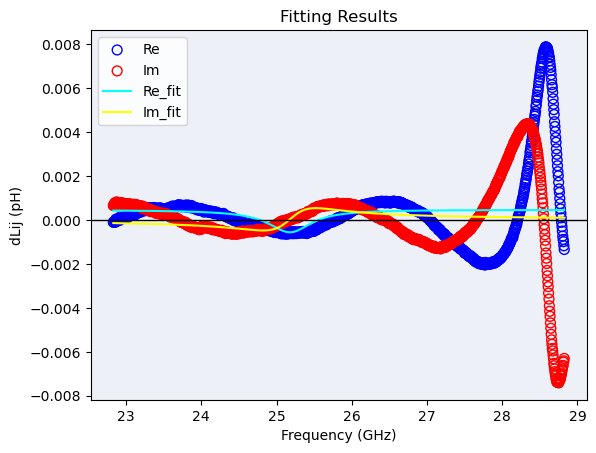


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.843e-05      7.359e-05         U        No
Ai                    -3.566e-04      7.359e-05         U        No
fo                       25.1869         0.0895       GHz        No
df                        0.3513         0.0895       GHz        No
re0                    4.509e-04      5.848e-05         U        No
im0                   -1.425e-06      5.848e-05         U        No
----------------------------------------------------------------------
Index= 54, Guide freq.=25.27782301911576


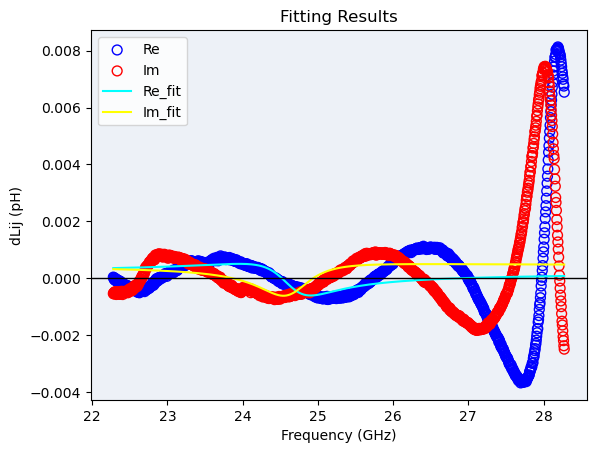


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.227e-04      8.556e-05         U        No
Ai                    -2.119e-04      8.556e-05         U        No
fo                       24.6418         0.0924       GHz        No
df                        0.4246         0.0924       GHz        No
re0                    1.954e-04      6.074e-05         U        No
im0                    4.345e-04      6.074e-05         U        No
----------------------------------------------------------------------
Index= 55, Guide freq.=24.74824889871193


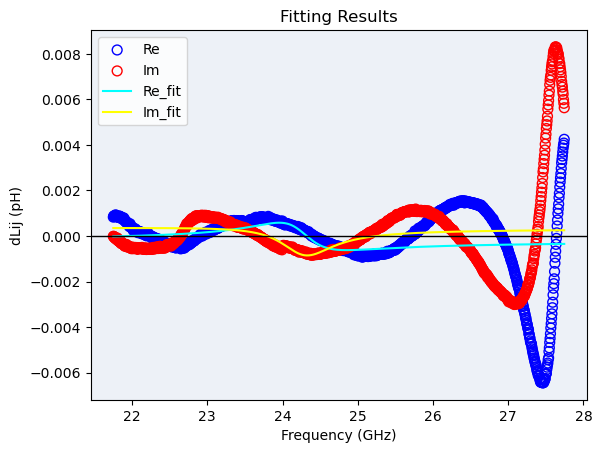


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.808e-04      8.359e-05         U        No
Ai                     1.677e-04      8.359e-05         U        No
fo                       24.2568         0.0837       GHz        No
df                        0.4228         0.0837       GHz        No
re0                   -2.166e-04      5.961e-05         U        No
im0                    3.169e-04      5.961e-05         U        No
----------------------------------------------------------------------
Index= 56, Guide freq.=24.171481858946137


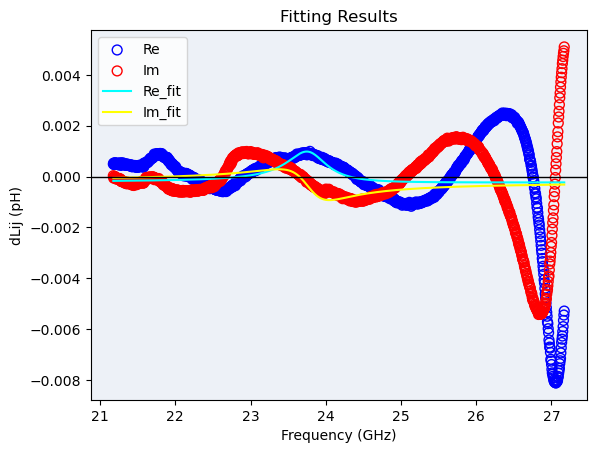


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.019e-05      6.592e-05         U        No
Ai                     3.926e-04      6.592e-05         U        No
fo                       23.7803         0.0678       GHz        No
df                        0.3297         0.0678       GHz        No
re0                   -2.161e-04      5.449e-05         U        No
im0                   -1.960e-04      5.449e-05         U        No
----------------------------------------------------------------------
Index= 57, Guide freq.=23.61393051655393


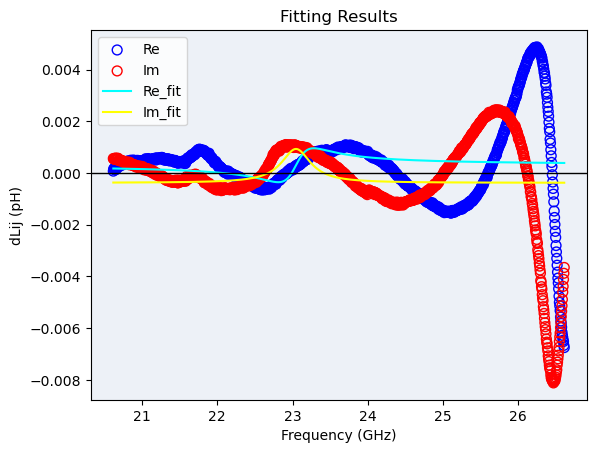


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.107e-04      5.350e-05         U        No
Ai                    -5.787e-07      5.350e-05         U        No
fo                       23.0450         0.0527       GHz        No
df                        0.2367         0.0527       GHz        No
re0                    3.026e-04      5.329e-05         U        No
im0                   -3.803e-04      5.329e-05         U        No
----------------------------------------------------------------------
Index= 58, Guide freq.=23.0529940792237


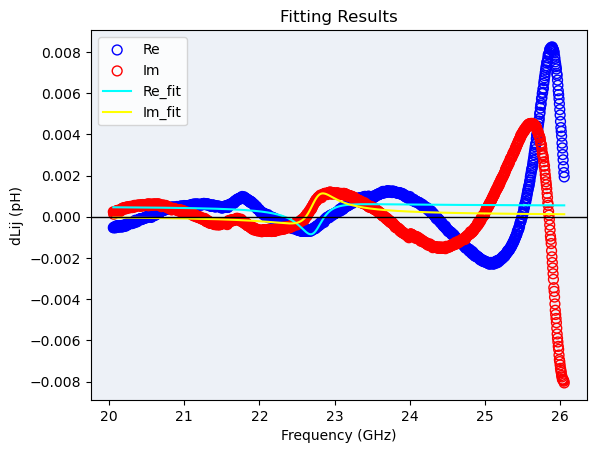


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.356e-04      4.840e-05         U        No
Ai                    -2.425e-04      4.840e-05         U        No
fo                       22.7321         0.0437       GHz        No
df                        0.1904         0.0437       GHz        No
re0                    5.175e-04      5.441e-05         U        No
im0                    4.881e-05      5.441e-05         U        No
----------------------------------------------------------------------
Index= 59, Guide freq.=22.510333532887593


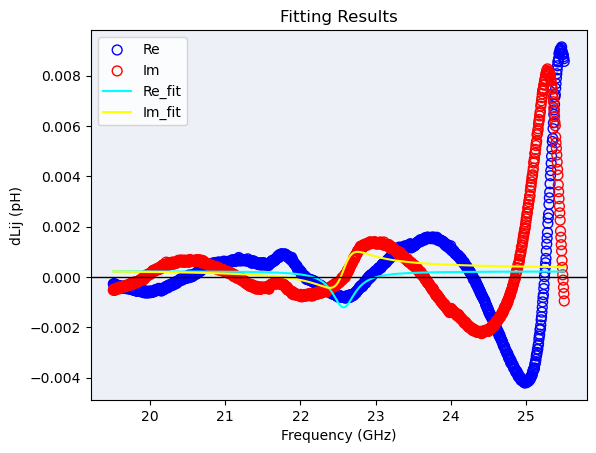


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -7.177e-06      5.121e-05         U        No
Ai                    -2.634e-04      5.121e-05         U        No
fo                       22.5714         0.0472       GHz        No
df                        0.1840         0.0472       GHz        No
re0                    2.233e-04      5.867e-05         U        No
im0                    3.015e-04      5.867e-05         U        No
----------------------------------------------------------------------
Index= 60, Guide freq.=21.91609056291237


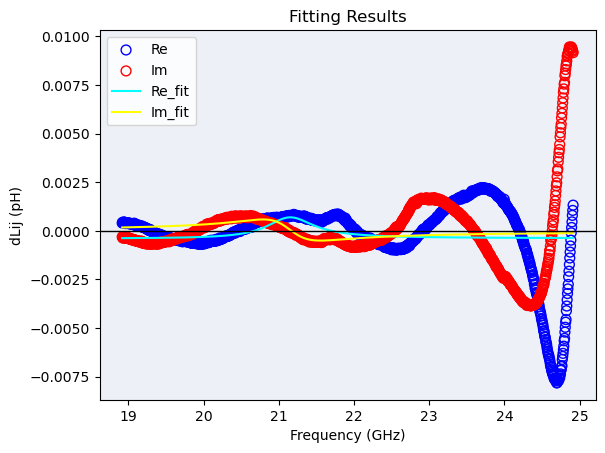


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.125e-05      8.769e-05         U        No
Ai                     4.141e-04      8.769e-05         U        No
fo                       21.1346         0.0983       GHz        No
df                        0.3826         0.0983       GHz        No
re0                   -3.915e-04      6.612e-05         U        No
im0                   -1.363e-05      6.612e-05         U        No
----------------------------------------------------------------------
Index= 61, Guide freq.=21.336057160520383


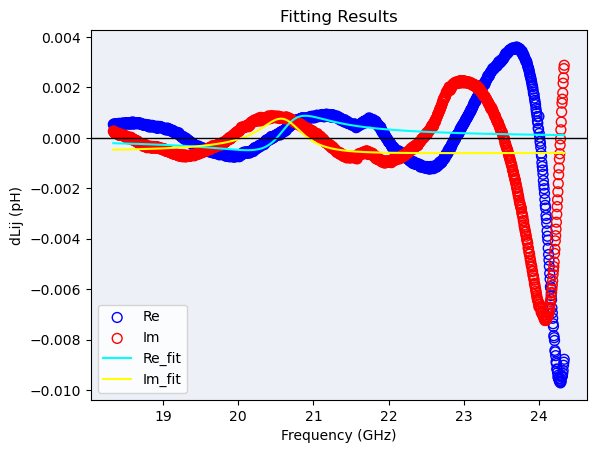


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.732e-04      8.446e-05         U        No
Ai                     1.562e-04      8.446e-05         U        No
fo                       20.6275         0.0761       GHz        No
df                        0.3652         0.0761       GHz        No
re0                   -2.030e-05      6.554e-05         U        No
im0                   -5.692e-04      6.554e-05         U        No
----------------------------------------------------------------------
Index= 62, Guide freq.=20.74448611602048


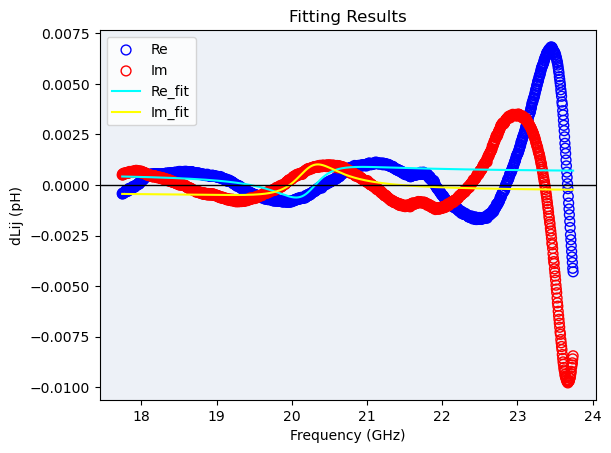


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.171e-04      8.061e-05         U        No
Ai                    -3.243e-04      8.061e-05         U        No
fo                       20.2265         0.0660       GHz        No
df                        0.3488         0.0660       GHz        No
re0                    6.042e-04      6.442e-05         U        No
im0                   -3.349e-04      6.442e-05         U        No
----------------------------------------------------------------------
Index= 63, Guide freq.=20.13773494825762


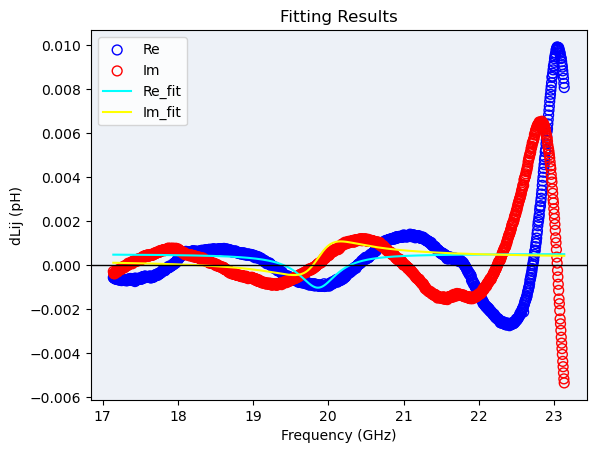


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.160e-05      7.277e-05         U        No
Ai                    -4.738e-04      7.277e-05         U        No
fo                       19.8691         0.0598       GHz        No
df                        0.3097         0.0598       GHz        No
re0                    5.002e-04      6.240e-05         U        No
im0                    2.751e-04      6.240e-05         U        No
----------------------------------------------------------------------
Index= 64, Guide freq.=19.51163130963349


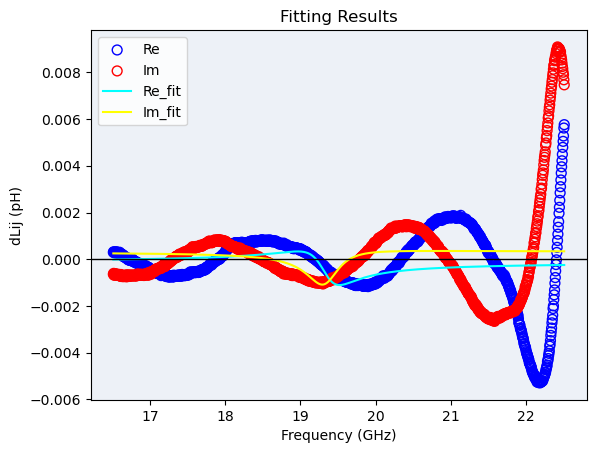


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.535e-04      6.034e-05         U        No
Ai                    -1.326e-04      6.034e-05         U        No
fo                       19.3392         0.0538       GHz        No
df                        0.2623         0.0538       GHz        No
re0                   -1.323e-04      5.687e-05         U        No
im0                    3.082e-04      5.687e-05         U        No
----------------------------------------------------------------------
Index= 65, Guide freq.=18.861596024697125


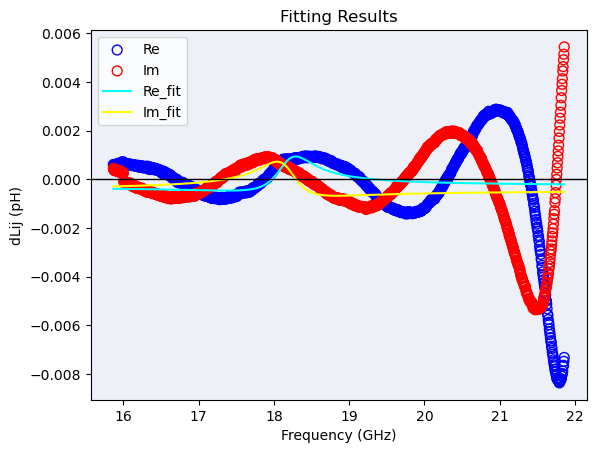


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.761e-04      6.672e-05         U        No
Ai                     3.132e-04      6.672e-05         U        No
fo                       18.1760         0.0600       GHz        No
df                        0.2975         0.0600       GHz        No
re0                   -2.902e-04      5.835e-05         U        No
im0                   -4.410e-04      5.835e-05         U        No
----------------------------------------------------------------------
Index= 66, Guide freq.=18.18279868266381


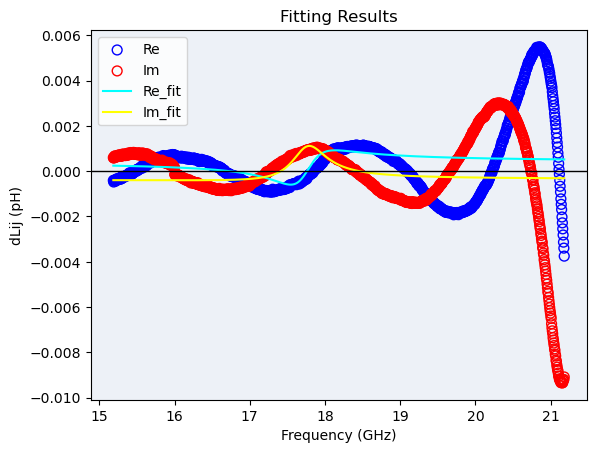


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.055e-04      6.496e-05         U        No
Ai                    -1.364e-04      6.496e-05         U        No
fo                       17.7465         0.0545       GHz        No
df                        0.2821         0.0545       GHz        No
re0                    4.057e-04      5.869e-05         U        No
im0                   -3.612e-04      5.869e-05         U        No
----------------------------------------------------------------------
Index= 67, Guide freq.=17.4703355501564


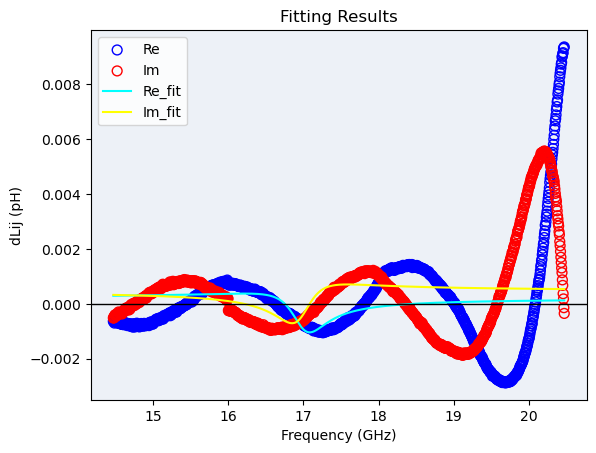


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.581e-04      6.086e-05         U        No
Ai                    -3.044e-04      6.086e-05         U        No
fo                       16.9809         0.0547       GHz        No
df                        0.2822         0.0547       GHz        No
re0                    2.067e-04      5.495e-05         U        No
im0                    4.580e-04      5.495e-05         U        No
----------------------------------------------------------------------
Index= 68, Guide freq.=16.75024618792746


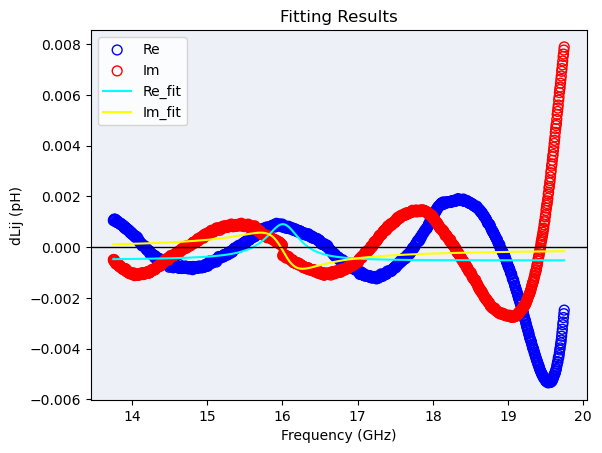


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.677e-05      5.445e-05         U        No
Ai                     3.907e-04      5.445e-05         U        No
fo                       16.0213         0.0486       GHz        No
df                        0.2759         0.0486       GHz        No
re0                   -5.133e-04      4.969e-05         U        No
im0                   -5.437e-05      4.969e-05         U        No
----------------------------------------------------------------------
Index= 69, Guide freq.=15.925510017352622


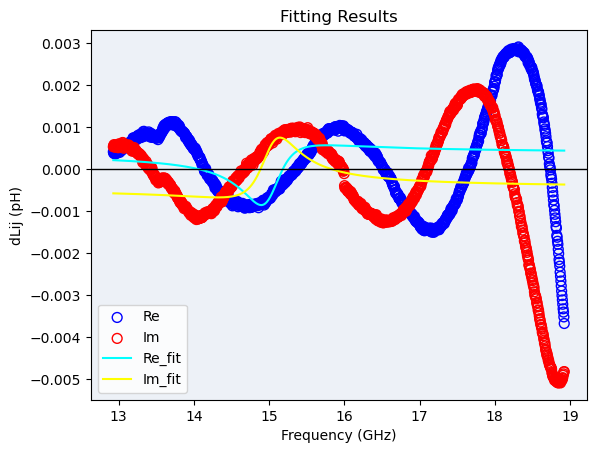


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.931e-04      4.919e-05         U        No
Ai                    -3.091e-04      4.919e-05         U        No
fo                       15.0154         0.0435       GHz        No
df                        0.2993         0.0435       GHz        No
re0                    3.700e-04      4.273e-05         U        No
im0                   -4.533e-04      4.273e-05         U        No
----------------------------------------------------------------------
Index= 70, Guide freq.=15.084477183674855


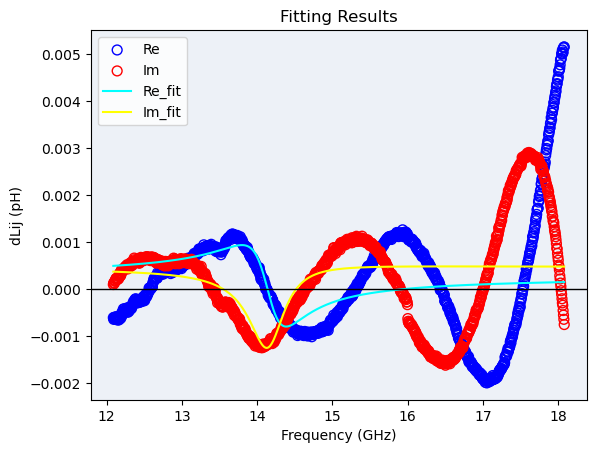


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.818e-04      4.128e-05         U        No
Ai                    -1.165e-04      4.128e-05         U        No
fo                       14.1606         0.0301       GHz        No
df                        0.2862         0.0301       GHz        No
re0                    2.724e-04      3.679e-05         U        No
im0                    4.571e-04      3.679e-05         U        No
----------------------------------------------------------------------
Index= 71, Guide freq.=14.192502099946168


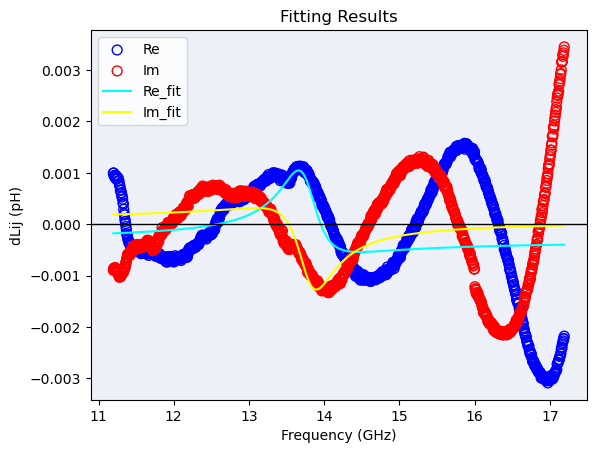


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.182e-04      3.710e-05         U        No
Ai                     3.234e-04      3.710e-05         U        No
fo                       13.7754         0.0297       GHz        No
df                        0.2858         0.0297       GHz        No
re0                   -3.123e-04      3.328e-05         U        No
im0                    7.906e-05      3.328e-05         U        No
----------------------------------------------------------------------
Index= 72, Guide freq.=13.245817383155314


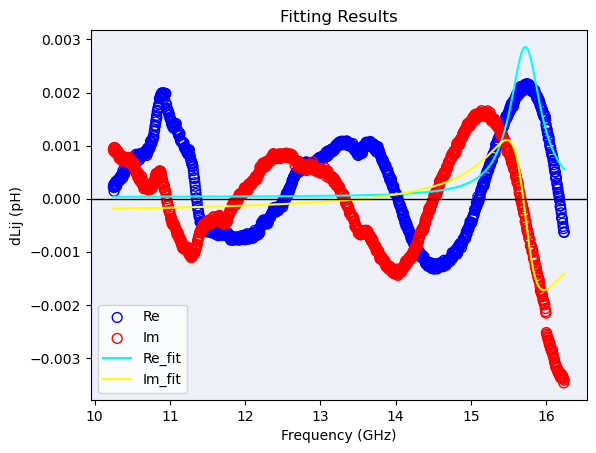


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.519e-06      3.198e-05         U        No
Ai                     6.938e-04      3.198e-05         U        No
fo                       15.7230         0.0134       GHz        No
df                        0.2453         0.0134       GHz        No
re0                    3.064e-05      2.783e-05         U        No
im0                   -3.163e-04      2.783e-05         U        No
----------------------------------------------------------------------
Index= 73, Guide freq.=12.239921402465212


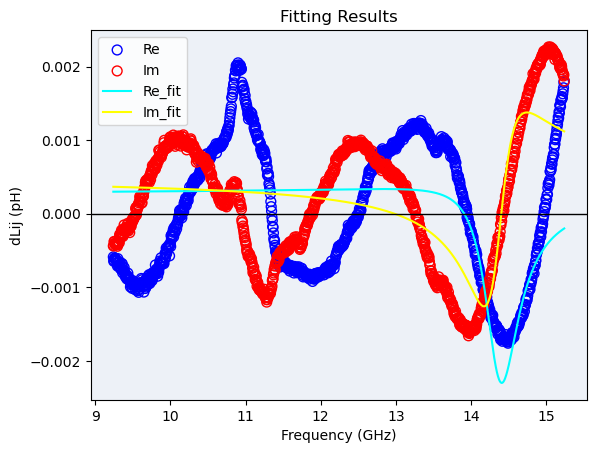


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.368e-04      2.853e-05         U        No
Ai                    -6.683e-04      2.853e-05         U        No
fo                       14.3595         0.0132       GHz        No
df                        0.2689         0.0132       GHz        No
re0                    2.611e-04      2.494e-05         U        No
im0                    4.999e-04      2.494e-05         U        No
----------------------------------------------------------------------
Index= 74, Guide freq.=11.167852019302009


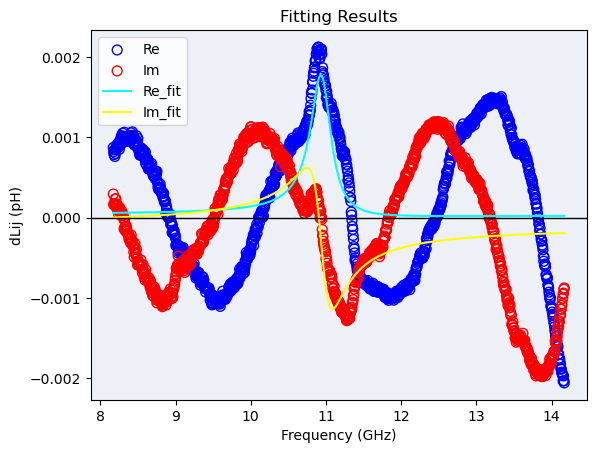


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -5.283e-05      2.139e-05         U        No
Ai                     2.877e-04      2.139e-05         U        No
fo                       10.9462         0.0162       GHz        No
df                        0.1668         0.0162       GHz        No
re0                    3.405e-05      2.584e-05         U        No
im0                   -1.008e-04      2.584e-05         U        No
----------------------------------------------------------------------
Index= 75, Guide freq.=10.016509068031116


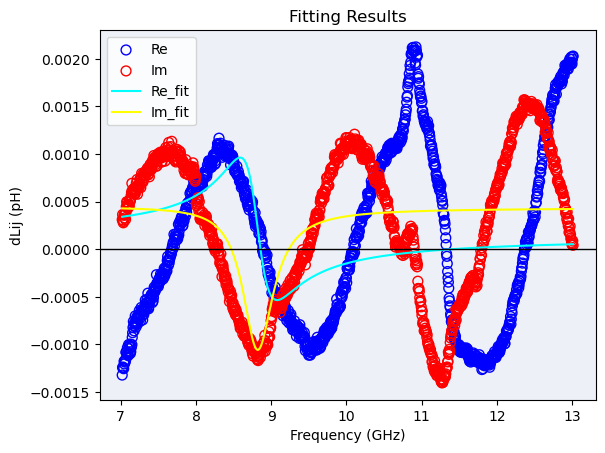


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.643e-04      2.688e-05         U        No
Ai                     3.701e-05      2.688e-05         U        No
fo                        8.8092         0.0230       GHz        No
df                        0.2445         0.0230       GHz        No
re0                    1.386e-04      2.606e-05         U        No
im0                    4.361e-04      2.606e-05         U        No
----------------------------------------------------------------------
Index= 76, Guide freq.=8.758529524393913


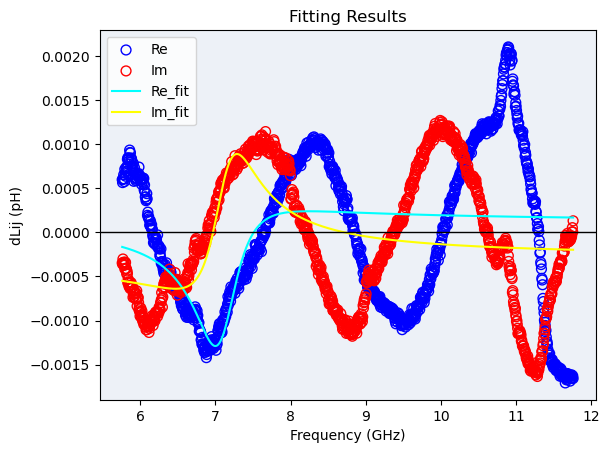


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.871e-04      3.338e-05         U        No
Ai                    -4.367e-04      3.338e-05         U        No
fo                        7.1027         0.0264       GHz        No
df                        0.3419         0.0264       GHz        No
re0                    1.139e-04      2.614e-05         U        No
im0                   -2.952e-04      2.614e-05         U        No
----------------------------------------------------------------------
Index= 77, Guide freq.=7.332125598132747


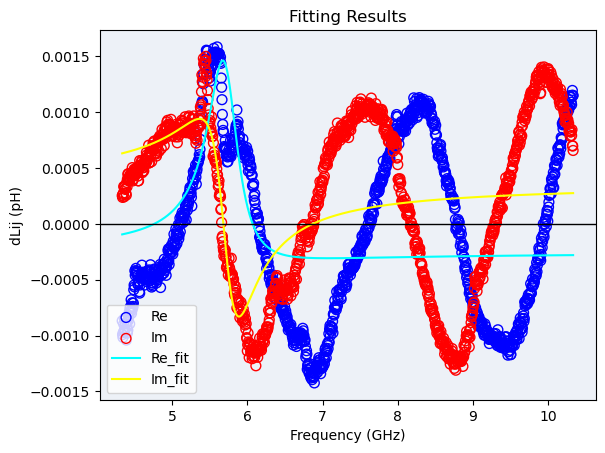


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.520e-04      2.326e-05         U        No
Ai                     4.069e-04      2.326e-05         U        No
fo                        5.7183         0.0166       GHz        No
df                        0.2454         0.0166       GHz        No
re0                   -2.513e-04      2.223e-05         U        No
im0                    3.651e-04      2.223e-05         U        No
----------------------------------------------------------------------
Index= 78, Guide freq.=5.576382527681739


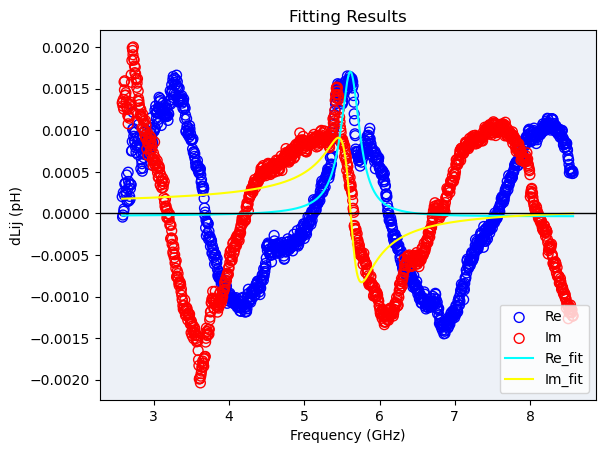


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.492e-05      1.935e-05         U        No
Ai                     2.653e-04      1.935e-05         U        No
fo                        5.6161         0.0149       GHz        No
df                        0.1528         0.0149       GHz        No
re0                   -3.358e-05      2.449e-05         U        No
im0                    8.936e-05      2.449e-05         U        No
----------------------------------------------------------------------
Index= 79, Guide freq.=2.817237039406515


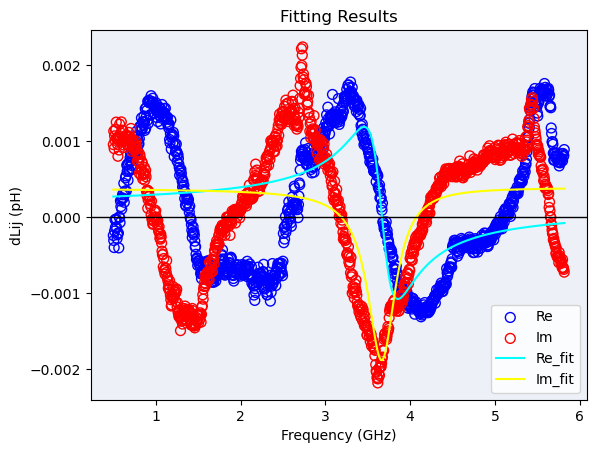


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.490e-04      2.241e-05         U        No
Ai                    -3.001e-05      2.241e-05         U        No
fo                        3.6699         0.0128       GHz        No
df                        0.1985         0.0128       GHz        No
re0                    1.285e-04      2.596e-05         U        No
im0                    3.788e-04      2.596e-05         U        No
----------------------------------------------------------------------
Index= 80, Guide freq.=4.000648140455164


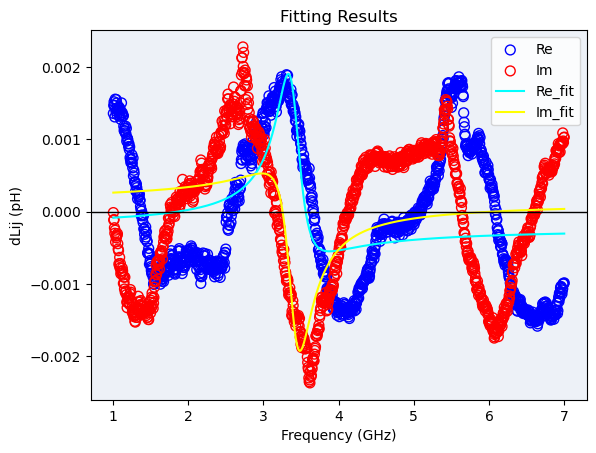


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.088e-04      2.364e-05         U        No
Ai                     3.339e-04      2.364e-05         U        No
fo                        3.4042         0.0127       GHz        No
df                        0.1855         0.0127       GHz        No
re0                   -2.222e-04      2.692e-05         U        No
im0                    1.346e-04      2.692e-05         U        No
----------------------------------------------------------------------


In [33]:
est_gamma = 28.8 #GHz/T
est_hx = 2150.0/1000 #T
est_hy = -15/1000 #T

for i in range(len(ansy1.calc_field("inP"))):
    H_index = i
    freq = res_func.kittel_general(ansy1.calc_field("inP")[H_index],est_gamma, est_hx, est_hy)
    print(f"Index= {i}, Guide freq.={freq}")
    ini_vals = [1, 1, freq, 0.028, 0, 0] #A, w, fres, fper, fref, re0, im0

    
    f_min, f_max = freq-3, freq+3 #GHz
    f_array = ansy1.freqs
    y_array_re, y_array_im = ansy1.d_S("21R")[H_index], ansy1.d_S("21I")[H_index]
    
    model = models.ComplexLorentzian_freq()
    fitter = fits.ComplexFitter( ini_vals, f_min, f_max,
        f_array, y_array_re , y_array_im, model)
    fitter.fix(fo=freq, df=0.02, re0=0, im0=0) # Parameters to be fixed, empty otherwise
    opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
    #print(opt_p0)
    #fitter.plot_fit_simplex_wpm()
    new_p0 = np.array(list(opt_p0.values()), dtype=float)
    fitter.update_p0(new_p0)
    
    params, cov = fitter.fit(simplex_b=False)
    fitter.plot_fit()
    fitter.summary()
    fit_dict = fitter.export_fit_dict()
    fits_storage.save(index=H_index,val=float(ansy1.calc_field("inP")[H_index]),fit_dict=fit_dict)

In [34]:
#Realoading parameters

In [35]:
data_L_fits = fits_storage.load_fit_results(newFile, group="Lorentzian fitting")

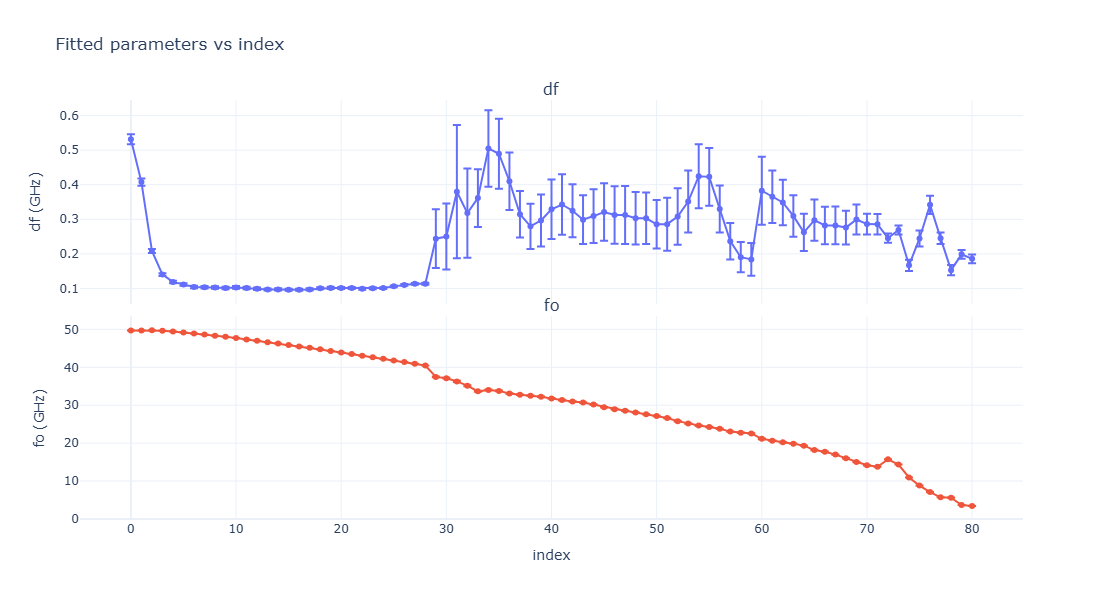

In [36]:
fits_storage.plot_fit_parameters_subplots(
    data_L_fits,
    x_axis="index",
    params=["df", "fo"],
    x_label= "index"#"μ₀H (T)"
)

In [37]:
cut_data_L_fits = fits_storage.slice_dict(data_L_fits, 15, 72)

In [ ]:
#Plotting of fitted parameters after cutting

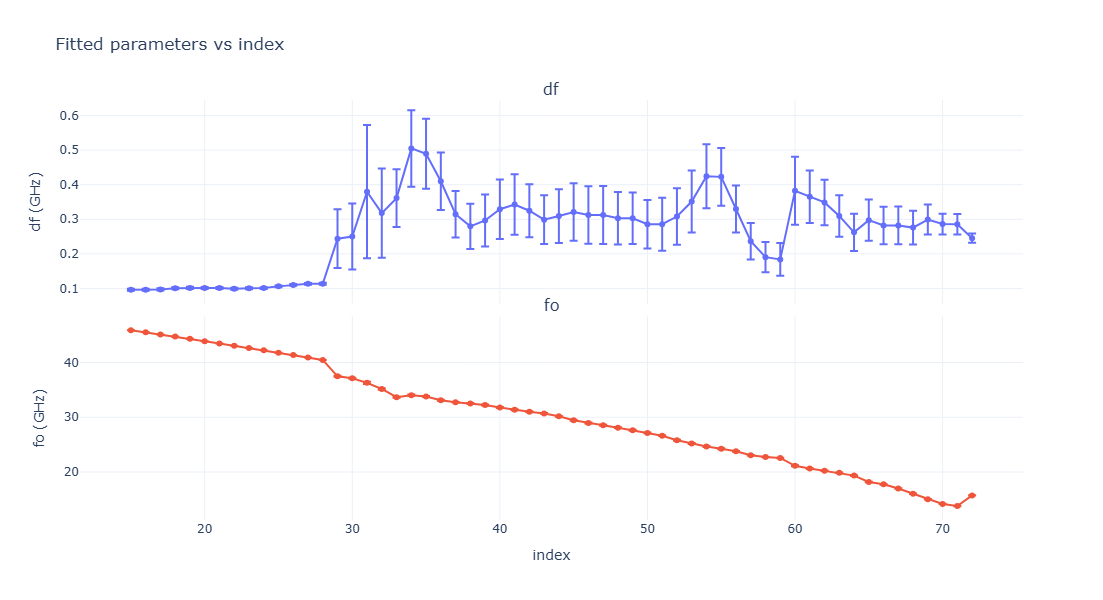

In [43]:
fits_storage.plot_fit_parameters_subplots(
    cut_data_L_fits,
    x_axis="index",
    params=["df", "fo"],
    x_label= "index"#"μ₀H (T)"
)